In [ ]:
pip install geopandas

In [ ]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 34.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install XGBClassifier

ERROR: Could not find a version that satisfies the requirement XGBClassifier (from versions: none)
ERROR: No matching distribution found for XGBClassifier


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import rasterio
import shap
import os
from rasterio.warp import reproject, Resampling

from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut, StratifiedKFold
from sklearn.utils import resample
from sklearn.svm import SVR,SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier   # <-- Correctofrom sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_regression # Usamos datos de regresión para el ejemplo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder


In [ ]:
PATH = "/content/drive/MyDrive/DATATHON CIP 2025"

In [ ]:
gdf_picotani = gpd.read_file(f"{PATH}/COBERTURA PICOTANI/01_Comunity/cc_picotani_WGS84.shp")
gdf_picotani_point = gpd.read_file(f"{PATH}/COBERTURA PICOTANI/Georeferencias/Georeferencias_Picotani.shp")

In [ ]:
gdf_picotani_point

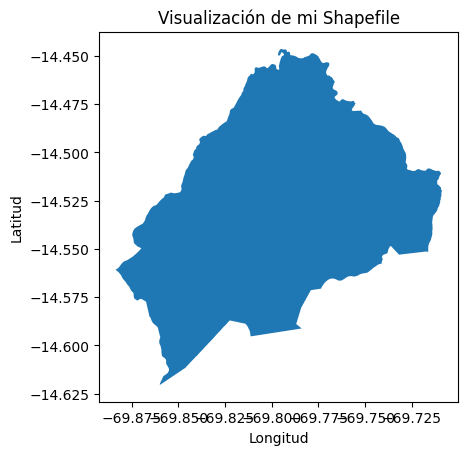

In [ ]:
gdf_picotani.plot()
plt.title("Visualización de mi Shapefile")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

In [ ]:
pip install earthengine-api

In [ ]:
import ee
import ee.batch # Para las exportaciones

# --- Autenticación y Carga ---

# ESTE ES EL ID DE TU PROYECTO (lo saqué de la ruta de tus assets)
MI_PROYECTO = 'rugged-plane-476315-d2'

try:
    # Intenta inicializar con tu ID de proyecto
    ee.Initialize(project=MI_PROYECTO)
except Exception as e:
    # Si falla, autentica (esto te pedirá el código del navegador)
    print("Por favor, autentícate con Google...")
    ee.Authenticate()
    # Y LUEGO inicializa de nuevo, pasándole tu ID de proyecto
    ee.Initialize(project=MI_PROYECTO)

print("\n¡Autenticación e Inicialización exitosas!")

# --- El resto de tu script (ya no es necesario modificarlo) ---

# 1. Cargar shapefile (Área de estudio)
# Asegúrate de haber subido tu shapefile a los Assets de ese proyecto
shapefile = ee.FeatureCollection(f'projects/{MI_PROYECTO}/assets/01_Comunity-20251026T153456Z-1-001')
# O el que estabas usando:
# shapefile = ee.FeatureCollection(f'projects/{MI_PROYECTO}/assets/Tambokarkas5')

geometry = shapefile.geometry()

# (El resto del script sigue igual...)


¡Autenticación e Inicialización exitosas!


In [ ]:
geometry = shapefile.geometry()

# No hay Map.addLayer() en Python, esto es solo para el Code Editor.
# La visualización se hace con otras librerías como geemap o folium.

# 2. Cargar colección Sentinel-2
s2 = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
      .filterBounds(geometry)
      .filterDate('2024-06-01', '2024-11-30')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .select(['B2','B3','B4','B8','B11']))

# 3. Crear imagen compuesta (mediana)
image = s2.median().clip(geometry)

# 4. Definir bandas (esto es idéntico)
blue = image.select('B2')
green = image.select('B3')
red = image.select('B4')
nir = image.select('B8')
swir = image.select('B11')

# --- Cálculo de índices espectrales (IDÉNTICO) ---

# NDVI
ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
# GNDVI
gndvi = nir.subtract(green).divide(nir.add(green)).rename('GNDVI')
# CIgreen
cigreen = nir.divide(green).subtract(1).rename('CIgreen')
# TNDVI
tndvi = nir.subtract(red).divide(nir.add(red)).add(0.5).sqrt().rename('TNDVI')
# OSAVI
osavi = nir.subtract(red).divide(nir.add(red).add(0.16)).multiply(1.16).rename('OSAVI')
# NDWI
ndwi = green.subtract(nir).divide(green.add(nir)).rename('NDWI')
# NDSVI
ndsvi = swir.subtract(red).divide(swir.add(red)).rename('NDSVI')
# NDPI
ndpi = red.subtract(swir).divide(red.add(swir)).rename('NDPI')
# NDGI
ndgi = green.subtract(red).divide(green.add(red)).rename('NDGI')

# --- Combinar todos los índices ---
indices = (ee.Image.cat([
    ndvi, gndvi, cigreen, tndvi, osavi, ndwi, ndsvi, ndpi, ndgi
]).clip(geometry))

# --- Exportar todos los índices como un solo GeoTIFF ---
# Aquí cambia la sintaxis: se crea una 'Tarea' (Task) y luego se inicia.

task = ee.batch.Export.image.toDrive(
    image=indices,
    description='Sentinel2_Indices_JunNov2024_Python',
    folder='GEE_Export_Python',
    fileNamePrefix='Sentinel2_Indices_JunNov2024',
    region=geometry,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

# Iniciar la tarea de exportación
task.start()

print("Tarea de exportación (multibanda) iniciada. Revisa la pestaña 'Tasks' en el Code Editor de GEE o el estado de la tarea aquí.")

# --- Exportar cada índice como archivo GeoTIFF (opcional) ---
exportList = ['NDVI', 'GNDVI', 'CIgreen', 'TNDVI', 'OSAVI', 'NDWI', 'NDSVI', 'NDPI', 'NDGI']

for indexName in exportList:
    img = indices.select(indexName)

    task_individual = ee.batch.Export.image.toDrive(
        image=img,
        description=f'{indexName}_Sentinel2_JunNov2024',
        folder='Indices_Sentinel2_JunNov2024_Python',
        fileNamePrefix=indexName,
        region=geometry,
        scale=10,
        crs='EPSG:4326',
        maxPixels=1e13
    )

    task_individual.start()
    print(f"Tarea de exportación iniciada para: {indexName}")

Tarea de exportación (multibanda) iniciada. Revisa la pestaña 'Tasks' en el Code Editor de GEE o el estado de la tarea aquí.
Tarea de exportación iniciada para: NDVI
Tarea de exportación iniciada para: GNDVI
Tarea de exportación iniciada para: CIgreen
Tarea de exportación iniciada para: TNDVI
Tarea de exportación iniciada para: OSAVI
Tarea de exportación iniciada para: NDWI
Tarea de exportación iniciada para: NDSVI
Tarea de exportación iniciada para: NDPI
Tarea de exportación iniciada para: NDGI


In [ ]:
geometry = shapefile.geometry()

# 2. Cargar colección Sentinel-2
s2 = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
      .filterBounds(geometry)
      .filterDate('2024-06-01', '2024-11-30')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      # 1. MODIFICACIÓN: Añadimos B5, B7, y B12 a la selección
      .select(['B2','B3','B4','B5','B7','B8','B11','B12']))

# 3. Crear imagen compuesta (mediana)
image = s2.median().clip(geometry)

# 4. Definir bandas
blue = image.select('B2')
green = image.select('B3')
red = image.select('B4')
nir = image.select('B8')
swir1 = image.select('B11') # Renombrado a swir1 para claridad

# 2. MODIFICACIÓN: Definimos las nuevas bandas
b5_red_edge1 = image.select('B5')
b7_red_edge3 = image.select('B7')
swir2 = image.select('B12')

# --- Cálculo de índices espectrales (IDÉNTICO) ---
# (Estos usan las bandas originales)
ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
gndvi = nir.subtract(green).divide(nir.add(green)).rename('GNDVI')
cigreen = nir.divide(green).subtract(1).rename('CIgreen')
tndvi = nir.subtract(red).divide(nir.add(red)).add(0.5).sqrt().rename('TNDVI')
osavi = nir.subtract(red).divide(nir.add(red).add(0.16)).multiply(1.16).rename('OSAVI')
ndwi = green.subtract(nir).divide(green.add(nir)).rename('NDWI')
ndsvi = swir1.subtract(red).divide(swir1.add(red)).rename('NDSVI')
ndpi = red.subtract(swir1).divide(red.add(swir1)).rename('NDPI')
ndgi = green.subtract(red).divide(green.add(red)).rename('NDGI')

# --- Combinar todos los índices Y LAS NUEVAS BANDAS ---
# 3. MODIFICACIÓN: Añadimos las nuevas bandas al ee.Image.cat()
all_outputs = (ee.Image.cat([
    green, b5_red_edge1, b7_red_edge3, swir1, swir2
]).clip(geometry))

# --- Exportar todo como un solo GeoTIFF ---
task = ee.batch.Export.image.toDrive(
    image=all_outputs, # Exportamos la imagen 'all_outputs'
    description='Sentinel2_Indices_y_Bandas_JunNov2024',
    folder='GEE_Export_Python',
    fileNamePrefix='Sentinel2_Indices_y_Bandas_JunNov2024',
    region=geometry,
    scale=10, # GEE remuestrea B5,B7,B11,B12 (20m) a 10m
    crs='EPSG:4326',
    maxPixels=1e13
)

# Iniciar la tarea de exportación
task.start()

print("Tarea de exportación (multibanda con índices y bandas) iniciada.")
print("Revisa la pestaña 'Tasks' en el Code Editor de GEE.")

# (He quitado la exportación individual para simplificar,
# ya que el primer archivo GeoTIFF ya contiene todo)

Tarea de exportación (multibanda con índices y bandas) iniciada.
Revisa la pestaña 'Tasks' en el Code Editor de GEE.


In [ ]:
gdf_picotani_point.shape

(441, 9)

In [ ]:
gdf_picotani_point['CLASES'].value_counts()

,count
CLASES,
CESP_PUNA,201
MIX0_FLOOD_CESP,68
NO_VEGET,46
FLOOD_VEGE,42
WATER_BO,23
MIX1_GRASS_CESP,20
GRASS_PA,20
MIX2_GRASS_ROQU,14
TOLARES,4


/tmp/ipython-input-4213383356.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend() # Muestra la leyenda (usando las 'label' que definimos)


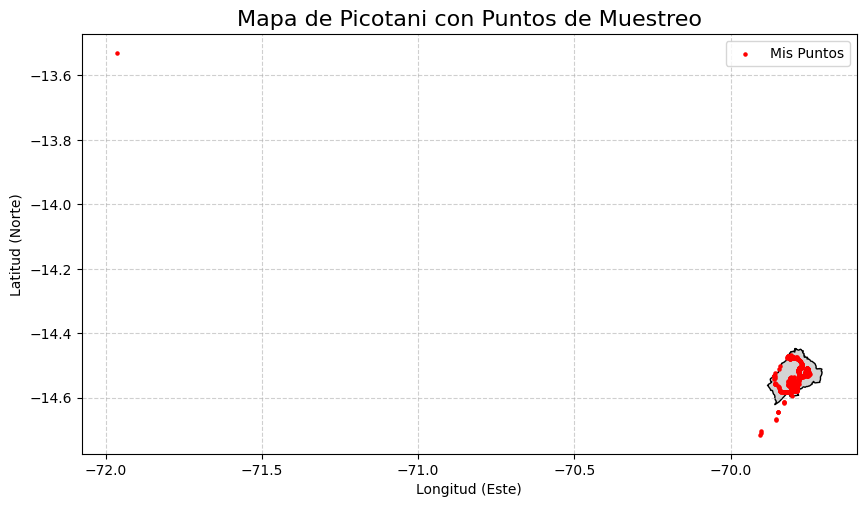

Gráfico mostrado.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# --- Paso A: Dibuja el mapa base (Picotani) en el lienzo 'ax'
gdf_picotani.plot(
    ax=ax,                  # ¡Importante! Dibuja en el lienzo 'ax'
    color='lightgray',      # Color de relleno del polígono
    edgecolor='black',      # Color del borde del polígono
    label='Límite Picotani' # Etiqueta para la leyenda
)

# --- Paso B: Dibuja los puntos encima, en el MISMO lienzo 'ax'
gdf_picotani_point.plot(
    ax=ax,                  # ¡Importante! Dibuja en el mismo lienzo 'ax'
    color='red',            # Color de los puntos
    markersize=5,           # Tamaño de los puntos
    label='Mis Puntos'      # Etiqueta para la leyenda
)

# --- 3. Añadir detalles al gráfico ---
ax.set_title("Mapa de Picotani con Puntos de Muestreo", fontsize=16)
ax.set_xlabel("Longitud (Este)")
ax.set_ylabel("Latitud (Norte)")
ax.legend() # Muestra la leyenda (usando las 'label' que definimos)
ax.grid(True, linestyle='--', alpha=0.6) # Añade una cuadrícula suave

# --- 4. Mostrar el gráfico ---
plt.show()

print("Gráfico mostrado.")

In [ ]:
print(gdf_picotani.crs)
print(gdf_picotani_point.crs)

EPSG:4326
EPSG:4326


In [ ]:
# Filtrar puntos dentro del polígono
gdf_inside = gdf_picotani_point[~gdf_picotani_point.within(gdf_picotani.geometry.iloc[0])]
gdf_inside_1 = gdf_inside['globalid'].to_list()
gdf_inside_1

['1f491acb-9f39-418a-9daf-e5c26e87e0ab',
 'db948cfc-a964-4ea5-b95a-6866a84a9b64',
 'a819d4b3-0598-4230-bfbc-7147edfa3f27',
 '2d2161e6-d477-4856-b652-bfda48afa7b1',
 'ebe4c4da-a3e3-4d9c-9dea-3c9c522fca2c',
 '731df85b-b4dc-467f-afdc-bc761d485ff6',
 '5184c1bb-b158-4f2c-8440-3e6d5cd3ff55',
 '8291b77e-2e42-4f4b-8854-3e2b269697d9',
 '3d277efc-ae4a-46bc-942c-3177aa4fb0f2',
 'ebadf920-e335-4068-8df2-b73e655682b2',
 '6e2da1e3-3e80-425a-8490-08c78c64a591',
 '53ce55a7-8ef0-4d65-b91c-cf3357f4eb6e',
 '147f6c0d-504e-4c22-ba48-b0af67232ec1',
 'c3536a63-e74c-4386-aec6-fe6b09a398ab']

In [ ]:
gdf_picotani_point_final = gdf_picotani_point[~gdf_picotani_point['globalid'].isin(gdf_inside_1)].reset_index(drop=True)
gdf_picotani_point_final

,globalid,HORA,CLASES,OBSERVACIO,CreationDa,Creator,EditDate,Editor,geometry
0,24583f9e-e36d-4134-b09e-44c32cb63c42,2024-08-08,MIX0_FLOOD_CESP,None,2024-08-19,None,2024-08-19,None,POINT (-69.80761 -14.55042)
1,4dff2ba6-be77-4934-9fd0-0e40042a808f,2024-08-08,CESP_PUNA,None,2024-08-19,None,2024-08-19,None,POINT (-69.80495 -14.54466)
2,576d90f4-eb4e-4bfe-98e5-1138d2776bdc,2024-08-08,CESP_PUNA,None,2024-08-19,None,2024-08-19,None,POINT (-69.80467 -14.5466)
3,6e74abca-2eb7-4425-9b20-4c13dbfb7f69,2024-08-08,MIX0_FLOOD_CESP,None,2024-08-19,None,2024-08-19,None,POINT (-69.80465 -14.54723)
4,d98a34d2-2d79-4ec2-bba8-a4ca5530104b,2024-08-09,CESP_PUNA,Rastro de vegetacion inundable seca,2024-08-19,None,2024-08-19,None,POINT (-69.80491 -14.56288)
...,...,...,...,...,...,...,...,...,...
422,a1723e22-107d-4c09-8ba8-3594666c4ca8,2025-06-04,WATER_BO,None,2025-06-25,None,2025-06-25,None,POINT (-69.81328 -14.565)
423,1184ee30-0ebe-4975-9c41-2fd289a0e577,2025-06-04,CESP_PUNA,None,2025-06-25,None,2025-06-25,None,POINT (-69.81605 -14.56073)
424,726fcde9-064c-4efc-a7b5-7e36e1077e86,2025-06-04,CESP_PUNA,None,2025-06-25,None,2025-06-25,None,POINT (-69.81559 -14.56235)
425,c5f94229-6ce2-4240-b4db-e1c266dfd6f0,2025-06-04,CESP_PUNA,None,2025-06-25,None,2025-06-25,None,POINT (-69.80808 -14.56417)


/tmp/ipython-input-1742803530.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend() # Muestra la leyenda (usando las 'label' que definimos)


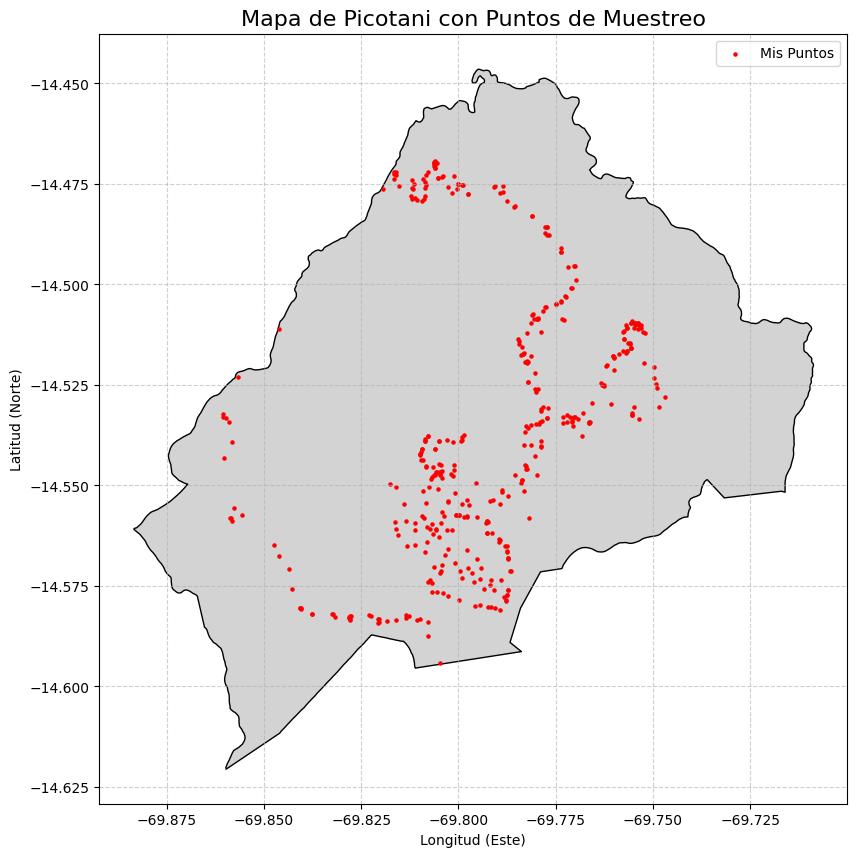

Gráfico mostrado.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# --- Paso A: Dibuja el mapa base (Picotani) en el lienzo 'ax'
gdf_picotani.plot(
    ax=ax,                  # ¡Importante! Dibuja en el lienzo 'ax'
    color='lightgray',      # Color de relleno del polígono
    edgecolor='black',      # Color del borde del polígono
    label='Límite Picotani' # Etiqueta para la leyenda
)

# --- Paso B: Dibuja los puntos encima, en el MISMO lienzo 'ax'
gdf_picotani_point_final.plot(
    ax=ax,                  # ¡Importante! Dibuja en el mismo lienzo 'ax'
    color='red',            # Color de los puntos
    markersize=5,           # Tamaño de los puntos
    label='Mis Puntos'      # Etiqueta para la leyenda
)

# --- 3. Añadir detalles al gráfico ---
ax.set_title("Mapa de Picotani con Puntos de Muestreo", fontsize=16)
ax.set_xlabel("Longitud (Este)")
ax.set_ylabel("Latitud (Norte)")
ax.legend() # Muestra la leyenda (usando las 'label' que definimos)
ax.grid(True, linestyle='--', alpha=0.6) # Añade una cuadrícula suave

# --- 4. Mostrar el gráfico ---
plt.show()

print("Gráfico mostrado.")

In [ ]:
os.listdir("/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/GEE_Export_Python")

['Sentinel2_Indices_JunNov2024.tif',
 'Sentinel2_Indices_y_Bandas_JunNov2024.tif']

In [ ]:
for i in os.listdir("/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/GEE_Export_Python"):
  ruta_a_mi_tiff = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/GEE_Export_Python/{i}"

  try:
      # 2. Abre el archivo GeoTIFF
      with rasterio.open(ruta_a_mi_tiff) as dataset:

          print(f"--- Información del archivo: {dataset.name} ---")

          # 3. Obtiene el número total de bandas
          num_bandas = dataset.count
          print(f"Número total de bandas: {num_bandas}")

          # 4. Obtiene los nombres (descripciones) de las bandas
          # GEE guarda aquí los nombres que pusiste con .rename()
          nombres_bandas = dataset.descriptions

          # 5. Obtiene los números (índices) de las bandas
          indices_bandas = dataset.indexes

          print("\n--- Lista de Bandas (Número: Nombre) ---")

          # 6. Combina los números y nombres y los imprime
          if nombres_bandas: # Si la lista de nombres no está vacía
              for numero, nombre in zip(indices_bandas, nombres_bandas):
                  print(f"Banda {numero}: {nombre}")
          else:
              # A veces los TIF no tienen nombres guardados
              print(f"El archivo no tiene nombres de banda. Los índices son: {indices_bandas}")

  except FileNotFoundError:
      print(f"Error: No se pudo encontrar el archivo en la ruta:")
      print(f"{ruta_a_mi_tiff}")
      print("Verifica que la ruta y el nombre del archivo sean correctos.")
  except Exception as e:
      print(f"Ocurrió un error al leer el archivo: {e}")

--- Información del archivo: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/GEE_Export_Python/Sentinel2_Indices_JunNov2024.tif ---
Número total de bandas: 9

--- Lista de Bandas (Número: Nombre) ---
Banda 1: NDVI
Banda 2: GNDVI
Banda 3: CIgreen
Banda 4: TNDVI
Banda 5: OSAVI
Banda 6: NDWI
Banda 7: NDSVI
Banda 8: NDPI
Banda 9: NDGI
--- Información del archivo: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/GEE_Export_Python/Sentinel2_Indices_y_Bandas_JunNov2024.tif ---
Número total de bandas: 5

--- Lista de Bandas (Número: Nombre) ---
Banda 1: B3
Banda 2: B5
Banda 3: B7
Banda 4: B11
Banda 5: B12


In [ ]:
import rasterio
import numpy as np

# 1. Define las rutas a tus archivos
ruta_tiff_1 = f"{PATH}/COBERTURA PICOTANI/GEE_Export_Python/Sentinel2_Indices_JunNov2024.tif"  # Ej: Los 9 índices
ruta_tiff_2 = f"{PATH}/COBERTURA PICOTANI/GEE_Export_Python/Sentinel2_Indices_y_Bandas_JunNov2024.tif" # Ej: Las 5 bandas
ruta_salida = f"{PATH}/COBERTURA PICOTANI/tiff_combinado.tif"

print(f"Abriendo {ruta_tiff_1}...")
# 2. Abre los dos archivos
with rasterio.open(ruta_tiff_1) as src1:
    # Lee todas las bandas del primer archivo
    data1 = src1.read()

    # Guarda el "perfil" (metadatos) del primer archivo.
    # Usaremos esto como plantilla para el archivo de salida.
    profile = src1.profile
    nombres_bandas_1 = src1.descriptions # Nombres de bandas (si los tiene)

    print(f"Abriendo {ruta_tiff_2}...")
    with rasterio.open(ruta_tiff_2) as src2:
        # Lee todas las bandas del segundo archivo
        data2 = src2.read()
        nombres_bandas_2 = src2.descriptions # Nombres de bandas

        # --- 3. El Paso Clave: Apilar las bandas ---
        # np.vstack apila los arrays verticalmente.
        # (Bandas, Alto, Ancho) + (Bandas, Alto, Ancho) -> (Total_Bandas, Alto, Ancho)
        print("Apilando bandas...")
        data_combinada = np.vstack((data1, data2))

        # Combina los nombres de las bandas
        nombres_combinados = nombres_bandas_1 + nombres_bandas_2

    # --- 4. Actualiza los metadatos para el nuevo archivo ---
    # Actualiza el número de bandas ('count')
    profile.update(
        count=data_combinada.shape[0],
        compress='lzw' # Añade compresión para que no sea tan pesado
    )

    # --- 5. Escribe el nuevo archivo GeoTIFF ---
    print(f"Guardando archivo combinado en {ruta_salida}...")
    with rasterio.open(ruta_salida, 'w', **profile) as dst:
        # Escribe los datos combinados
        dst.write(data_combinada)

        # Escribe los nombres de las bandas
        for i, nombre in enumerate(nombres_combinados):
            dst.set_band_description(i + 1, nombre)

print("\n--- ¡Proceso completado! ---")
print(f"Archivo 1 tenía {data1.shape[0]} bandas.")
print(f"Archivo 2 tenía {data2.shape[0]} bandas.")
print(f"El nuevo archivo tiene {data_combinada.shape[0]} bandas.")

Abriendo /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/GEE_Export_Python/Sentinel2_Indices_JunNov2024.tif...
Abriendo /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/GEE_Export_Python/Sentinel2_Indices_y_Bandas_JunNov2024.tif...
Apilando bandas...
Guardando archivo combinado en /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/tiff_combinado.tif...

--- ¡Proceso completado! ---
Archivo 1 tenía 9 bandas.
Archivo 2 tenía 5 bandas.
El nuevo archivo tiene 14 bandas.


In [ ]:
# =============================================================#
# Ruta para guardar el nuevo shapefile con los datos extraídos
# =============================================================#

ruta_shp_salida = f'{PATH}/COBERTURA PICOTANI/transectos_finales.shp'

# BANDA COMPLETA
ruta_tif = f'{PATH}/COBERTURA PICOTANI/tiff_combinado.tif'

# ================================================================
# 2. CARGAR LOS ARCHIVOS VECTORIAL (SHP) Y RASTER (TIF)
# ================================================================
print("Cargando archivos...")
# Cargar los puntos del shapefile en un GeoDataFrame
gdf_puntos = gdf_picotani_point_final # SHAPE FINAL

# Abrir el archivo TIF
src_raster = rasterio.open(ruta_tif)

print(f"Se cargaron {len(gdf_puntos)} puntos desde el SHP.")
print(f"El raster tiene {src_raster.count} banda(s).")


# ================================================================
# 3. VERIFICAR Y ALINEAR EL SISTEMA DE COORDENADAS (CRS)
# ================================================================
# ¡Este es el paso más importante! Ambos archivos deben tener el mismo CRS.
print(f"CRS del SHP: {gdf_puntos.crs}")
print(f"CRS del TIF: {src_raster.crs}")

if gdf_puntos.crs != src_raster.crs:
    print("\n¡Advertencia! Los CRS no coinciden. Reproyectando los puntos al CRS del raster...")
    gdf_puntos = gdf_puntos.to_crs(src_raster.crs)
    print(f"Nuevo CRS del SHP: {gdf_puntos.crs}")


# ================================================================
# 4. EXTRAER LOS VALORES DEL RASTER PARA CADA PUNTO
# ================================================================
# Obtener las coordenadas (x, y) de cada punto
coords = [(p.x, p.y) for p in gdf_puntos.geometry]

print("\nExtrayendo valores del raster para cada punto...")
# Usar el método 'sample' de rasterio para obtener los valores de los píxeles
# Esto devuelve un generador, por lo que lo convertimos en una lista
# Cada valor es un array (uno por cada banda del raster)
valores_raster = [val for val in src_raster.sample(coords)]

# Cerrar el archivo raster
src_raster.close()

print("Extracción completada.")

# ================================================================
# 5. AÑADIR LOS VALORES EXTRAÍDOS AL GEO DATAFRAME
# ================================================================
# Si tu TIF tiene UNA SOLA BANDA:
if len(valores_raster[0]) == 1:
    # Aplanar la lista y añadirla como una nueva columna
    gdf_puntos['valor_tif'] = [val[0] for val in valores_raster]

# Si tu TIF tiene MÚLTIPLES BANDAS (como en tu ejemplo anterior):
else:
    print(f"El raster es multibanda. Se crearán {len(valores_raster[0])} columnas nuevas.")
    # Extraer los datos por banda y crear una columna para cada una
    # Transponemos la matriz de valores para que cada fila sea un punto y cada columna una banda
    datos_por_banda = list(zip(*valores_raster))
    for i, banda_valores in enumerate(datos_por_banda):
        nombre_columna = f'banda_{i+1}'
        gdf_puntos[nombre_columna] = banda_valores


# Mostrar las primeras filas del resultado
print("\nVista previa del resultado:")
print(gdf_puntos.head())


# ================================================================
# 6. GUARDAR EL RESULTADO EN UN NUEVO SHAPEFILE
# ================================================================
try:
    gdf_puntos.to_file(ruta_shp_salida, driver='ESRI Shapefile')
    print(f"\n¡Éxito! Se ha guardado el nuevo shapefile en: {ruta_shp_salida}")
except Exception as e:
    print(f"\nError al guardar el archivo: {e}")

Cargando archivos...
Se cargaron 427 puntos desde el SHP.
El raster tiene 14 banda(s).
CRS del SHP: EPSG:4326
CRS del TIF: EPSG:4326

Extrayendo valores del raster para cada punto...
Extracción completada.
El raster es multibanda. Se crearán 14 columnas nuevas.

Vista previa del resultado:
                               globalid       HORA           CLASES  \
0  24583f9e-e36d-4134-b09e-44c32cb63c42 2024-08-08  MIX0_FLOOD_CESP   
1  4dff2ba6-be77-4934-9fd0-0e40042a808f 2024-08-08        CESP_PUNA   
2  576d90f4-eb4e-4bfe-98e5-1138d2776bdc 2024-08-08        CESP_PUNA   
3  6e74abca-2eb7-4425-9b20-4c13dbfb7f69 2024-08-08  MIX0_FLOOD_CESP   
4  d98a34d2-2d79-4ec2-bba8-a4ca5530104b 2024-08-09        CESP_PUNA   

                            OBSERVACIO CreationDa Creator   EditDate Editor  \
0                                 None 2024-08-19    None 2024-08-19   None   
1                                 None 2024-08-19    None 2024-08-19   None   
2                                 None 2024-0

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field HORA create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field CreationDa create as date field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field EditDate create as date field, though DateTime requested.
  ogr_write(


In [ ]:
gdf_puntos.columns

Index(['globalid', 'HORA', 'CLASES', 'OBSERVACIO', 'CreationDa', 'Creator',
       'EditDate', 'Editor', 'geometry', 'banda_1', 'banda_2', 'banda_3',
       'banda_4', 'banda_5', 'banda_6', 'banda_7', 'banda_8', 'banda_9',
       'banda_10', 'banda_11', 'banda_12', 'banda_13', 'banda_14'],
      dtype='object')

In [ ]:
columna = ['CLASES','banda_1', 'banda_2', 'banda_3',
       'banda_4', 'banda_5', 'banda_6', 'banda_7', 'banda_8', 'banda_9',
       'banda_10', 'banda_11', 'banda_12', 'banda_13', 'banda_14']

gdf_puntos_1 = pd.DataFrame(gdf_puntos[columna].values, columns=['CLASES',
 "NDVI","GNDVI",
    "CIgreen",
    "TNDVI",
    "OSAVI",
    "NDWI",
    "NDSVI",
    "NDPI",
    "NDGI",
    "B3",
    "B5",
    "B7",
    "B11",
    "B12"])
gdf_puntos_1['CLASES'].value_counts()

,count
CLASES,
CESP_PUNA,198
MIX0_FLOOD_CESP,66
NO_VEGET,45
FLOOD_VEGE,40
WATER_BO,21
MIX1_GRASS_CESP,19
GRASS_PA,18
MIX2_GRASS_ROQU,14
TOLARES,4


In [ ]:
mapa_categorias = {
    'FLOOD_VEGE': 'Bofedal - Flooded Vegetation',
    'CROPLAND': 'Cropland',
    'NO_VEGET': 'No vegetation',
    'MIX0_FLOOD_CESP': 'Non perennial Bofedal with Grass Cover',
    'GRASS_PA': 'Pajonal',
    'MIX1_GRASS_CESP': 'Pajonal and Puna Grassland',
    'MIX2_GRASS_ROQU': 'Pajonal, Grassland and Rock Outcrop',
    'CESP_PUNA': 'Puna Grassland',
    'TOLARES': 'Tolares',
    'WATER_BO': 'Water body'
}
gdf_puntos_1['CLASES'] = gdf_puntos_1['CLASES'].map(mapa_categorias)
gdf_puntos_1['CLASES'].value_counts(dropna=False)

,count
CLASES,
Puna Grassland,198
Non perennial Bofedal with Grass Cover,66
No vegetation,45
Bofedal - Flooded Vegetation,40
Water body,21
Pajonal and Puna Grassland,19
Pajonal,18
"Pajonal, Grassland and Rock Outcrop",14
Tolares,4


In [ ]:
mapa_grupos_ml = {
    # Grupo 1: Pastizal_Seco
    'Puna Grassland': 'Pastizal_Seco',
    'Pajonal and Puna Grassland': 'Pastizal_Seco',
    'Pajonal': 'Pastizal_Seco',

    # Grupo 2: Bofedal
    'Non perennial Bofedal with Grass Cover': 'Bofedal',
    'Bofedal - Flooded Vegetation': 'Bofedal',

    # Grupo 3: No_Productivo
    'No vegetation': 'No_Productivo',
    'Pajonal, Grassland and Rock Outcrop': 'No_Productivo',
    'Tolares': 'No_Productivo',

    # Grupo 4: Agua
    'Water body': 'Agua',

    # Exclusiones (se mapean a 'Nulo' y luego se eliminan)
    'Cropland': pd.NA,
    'NaN': pd.NA # Si 'NaN' es un string en tus datos
}

# --- Ejemplo de cómo usarlo ---
# 1. Crea la nueva columna 'GRUPO_ML'
# (Asumiendo que tus categorías originales están en 'CLASES_NOMBRE_COMPLETO')
gdf_puntos_1['GRUPO_ML'] = gdf_puntos_1['CLASES'].map(mapa_grupos_ml)

gdf_puntos_1.dropna(subset=['GRUPO_ML'], inplace=True)


,CLASES,NDVI,GNDVI,CIgreen,TNDVI,OSAVI,NDWI,NDSVI,NDPI,NDGI,B3,B5,B7,B11,B12,GRUPO_ML
0,Non perennial Bofedal with Grass Cover,0.224824,0.32644,0.969298,0.851366,0.260786,-0.32644,0.375801,-0.375801,-0.109665,1368.0,1924.0,2457.0,3758.0,2631.0,Bofedal
1,Puna Grassland,0.233063,0.341491,1.037165,0.856191,0.270342,-0.341491,0.36824,-0.36824,-0.117804,1157.0,1582.0,2065.0,3175.0,2051.0,Pastizal_Seco
2,Puna Grassland,0.217286,0.313764,0.914449,0.846927,0.25204,-0.313764,0.411096,-0.411096,-0.103536,1052.0,1491.0,1892.0,3103.0,2163.0,Pastizal_Seco
3,Non perennial Bofedal with Grass Cover,0.34215,0.425157,1.47921,0.917687,0.396876,-0.425157,0.456532,-0.456532,-0.097137,962.0,1524.0,2149.0,3133.0,1929.0,Bofedal
4,Puna Grassland,0.226388,0.369014,1.169643,0.852284,0.262602,-0.369014,0.328851,-0.328851,-0.155627,1568.0,2360.0,3022.0,4249.0,2594.0,Pastizal_Seco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,Water body,0.222354,0.35308,1.091572,0.849914,0.257921,-0.35308,0.381195,-0.381195,-0.141864,1234.0,1884.0,2441.0,3665.0,2361.0,Agua
423,Puna Grassland,0.255013,0.349364,1.073917,0.868915,0.295803,-0.349364,0.427725,-0.427725,-0.10358,1177.0,1716.0,2315.0,3615.0,2369.0,Pastizal_Seco
424,Puna Grassland,0.200967,0.339382,1.027468,0.837238,0.233114,-0.339382,0.350608,-0.350608,-0.148546,1347.0,1967.0,2509.0,3779.0,2436.0,Pastizal_Seco
425,Puna Grassland,0.205691,0.320755,0.944444,0.840054,0.238593,-0.320755,0.426253,-0.426253,-0.123191,1242.0,1851.0,2284.0,3955.0,2671.0,Pastizal_Seco


In [239]:
gdf_puntos_1['NDVI'] = gdf_puntos_1['NDVI'].astype(float)
gdf_puntos_1['GNDVI'] = gdf_puntos_1['GNDVI'].astype(float)
gdf_puntos_1['CIgreen'] = gdf_puntos_1['CIgreen'].astype(float)
gdf_puntos_1['TNDVI'] = gdf_puntos_1['TNDVI'].astype(float)
gdf_puntos_1['OSAVI'] = gdf_puntos_1['OSAVI'].astype(float)
gdf_puntos_1['NDWI'] = gdf_puntos_1['NDWI'].astype(float)
gdf_puntos_1['NDSVI'] = gdf_puntos_1['NDSVI'].astype(float)
gdf_puntos_1['NDPI'] = gdf_puntos_1['NDPI'].astype(float)
gdf_puntos_1['NDGI'] = gdf_puntos_1['NDGI'].astype(float)
gdf_puntos_1['B3'] = gdf_puntos_1['B3'].astype(float)
gdf_puntos_1['B5'] = gdf_puntos_1['B5'].astype(float)
gdf_puntos_1['B7'] = gdf_puntos_1['B7'].astype(float)
gdf_puntos_1['B11'] = gdf_puntos_1['B11'].astype(float)
gdf_puntos_1['B12'] = gdf_puntos_1['B12'].astype(float)
gdf_puntos_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 425 entries, 0 to 426
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CLASES    425 non-null    object 
 1   NDVI      425 non-null    float64
 2   GNDVI     425 non-null    float64
 3   CIgreen   425 non-null    float64
 4   TNDVI     425 non-null    float64
 5   OSAVI     425 non-null    float64
 6   NDWI      425 non-null    float64
 7   NDSVI     425 non-null    float64
 8   NDPI      425 non-null    float64
 9   NDGI      425 non-null    float64
 10  B3        425 non-null    float64
 11  B5        425 non-null    float64
 12  B7        425 non-null    float64
 13  B11       425 non-null    float64
 14  B12       425 non-null    float64
 15  GRUPO_ML  425 non-null    object 
dtypes: float64(14), object(2)
memory usage: 72.6+ KB


In [232]:
gdf_puntos_1.describe()

,NDVI,GNDVI,CIgreen,TNDVI,OSAVI,NDWI,NDSVI,NDPI,NDGI,B3,B5,B7,B11
count,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000
mean,0.233992,0.336587,1.042447,0.855829,0.271419,-0.336587,0.399251,-0.399251,-0.111513,1216.305147,1783.257227,2303.012325,3538.823922
std,0.068955,0.062079,0.301852,0.039392,0.079984,0.062079,0.062798,0.062798,0.027667,210.309159,291.725246,364.049740,430.524741
min,0.082901,0.145517,0.340598,0.763479,0.096162,-0.570706,0.158535,-0.574410,-0.222930,754.000000,1089.000000,1379.000000,2222.000000
25%,0.192443,0.305575,0.880081,0.832132,0.223227,-0.369014,0.368240,-0.435939,-0.126200,1064.000000,1588.000000,2059.000000,3274.000000
50%,0.221083,0.335782,1.011058,0.849166,0.256446,-0.335782,0.406449,-0.406449,-0.109890,1201.000000,1764.000000,2284.000000,3610.000000
75%,0.263135,0.369014,1.169643,0.873576,0.305225,-0.305575,0.435939,-0.368240,-0.094845,1334.000000,1966.000000,2572.000000,3839.000000
max,0.549430,0.570706,2.658810,1.024417,0.637314,-0.145517,0.574410,-0.158535,-0.004479,2022.000000,3211.500000,3826.000000,4646.000000


In [ ]:
'''
X = gdf_puntos_1[[
     'NDVI', 'GNDVI', 'CIgreen', 'TNDVI', 'OSAVI', 'NDWI', 'NDSVI',
     'NDPI', 'NDGI', 'B3', 'B5', 'B7', 'B11', 'B12']]
     '''

X = gdf_puntos_1[["B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"]]
y = gdf_puntos_1['GRUPO_ML']

# 2. Dividir en Train/Test con ESTRATIFICACIÓN
print(f"Total de muestras: {len(y)}")
print("Proporción original de clases:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # <--- AQUÍ ESTÁ LA MAGIA
)

print("\nProporción en y_train (estratificado):")
print(y_train.value_counts(normalize=True))
print("\nProporción en y_test (estratificado):")
print(y_test.value_counts(normalize=True))


# 3. Escalar los datos (sin cambios aquí)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Total de muestras: 425
Proporción original de clases:
GRUPO_ML
Pastizal_Seco    0.552941
Bofedal          0.249412
No_Productivo    0.148235
Agua             0.049412
Name: proportion, dtype: float64

Proporción en y_train (estratificado):
GRUPO_ML
Pastizal_Seco    0.552941
Bofedal          0.250000
No_Productivo    0.147059
Agua             0.050000
Name: proportion, dtype: float64

Proporción en y_test (estratificado):
GRUPO_ML
Pastizal_Seco    0.552941
Bofedal          0.247059
No_Productivo    0.152941
Agua             0.047059
Name: proportion, dtype: float64


In [242]:
gdf_puntos_1['B3'] = gdf_puntos_1['B3']/10000

# **Modelos**

## SVM

In [329]:
feature_names = X.columns.tolist()

In [360]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True)) # Usamos 'svc'
])

param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 100]
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.1, 0.01]
    }
]

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv_estratificado,

    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1 # Añadido para que veas el progreso
)

print("Iniciando la búsqueda de hiperparámetros para SVC...")
# Asegúrate de que X_train y y_train son los datos *originales*
# (El escalador está DENTRO del pipeline)
grid_search.fit(X_train, y_train)
print("Búsqueda completada.")

print("\n" + "="*50 + "\n")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
best_f1_score = grid_search.best_score_
print(f"Mejor F1-Score (ponderado) en CV: {best_f1_score:.4f}")
print("="*50 + "\n")

best_model = grid_search.best_estimator_
predictions_train_svm = best_model.predict(X_train)
predictions_test_svm = best_model.predict(X_test)


# --- 8. (BONUS) Importancia de Features (para SVC) ---
print("\n--- Importancia de Features (SVC) ---")

# Extraemos el modelo SVC entrenado del pipeline
svc_model = best_model.named_steps['svc']

# Comprobamos qué kernel eligió el GridSearchCV
best_kernel = svc_model.kernel
print(f"El mejor kernel encontrado fue: '{best_kernel}'")

if best_kernel == 'linear':
    # Si es 'linear', podemos usar los coeficientes (.coef_)
    # Para multi-clase (4 clases), .coef_ tiene una forma de (6, n_features)
    # Tomamos el valor absoluto (magnitud) y promediamos por feature
    importances_svc = np.mean(np.abs(svc_model.coef_), axis=0)

    # Creamos un DataFrame para verlo bonito
    df_imp_svc = pd.DataFrame({
        'Feature': feature_names,
        'Importancia (magnitud coef.)': importances_svc
    }).sort_values(by='Importancia (magnitud coef.)', ascending=False)

    print(df_imp_svc.head(10))

else:
    # Si es 'rbf' (o 'poly'), no existe .coef_ ni .feature_importances_
    print(f"El kernel '{best_kernel}' no tiene un atributo .feature_importances_ o .coef_.")
    print("Para este kernel, la 'importancia' debe calcularse con SHAP (como hiciste antes).")


Iniciando la búsqueda de hiperparámetros para SVC...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Búsqueda completada.


Mejores Hiperparámetros: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Mejor F1-Score (ponderado) en CV: 0.7612


--- Importancia de Features (SVC) ---
El mejor kernel encontrado fue: 'rbf'
El kernel 'rbf' no tiene un atributo .feature_importances_ o .coef_.
Para este kernel, la 'importancia' debe calcularse con SHAP (como hiciste antes).


--- Métricas en el Conjunto Entrenamiento (Train) ---
Accuracy (Exactitud): 0.7941 (79.41%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00        17
      Bofedal       0.86      0.69      0.77        85
No_Productivo       0.89      0.68      0.77        50
Pastizal_Seco       0.76      0.94      0.84       188

     accuracy                           0.79       340
    macro avg       0.63      0.58      0.59       340
 weighted avg       0.77      0.79      0.77       340


Matriz de Confusión:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


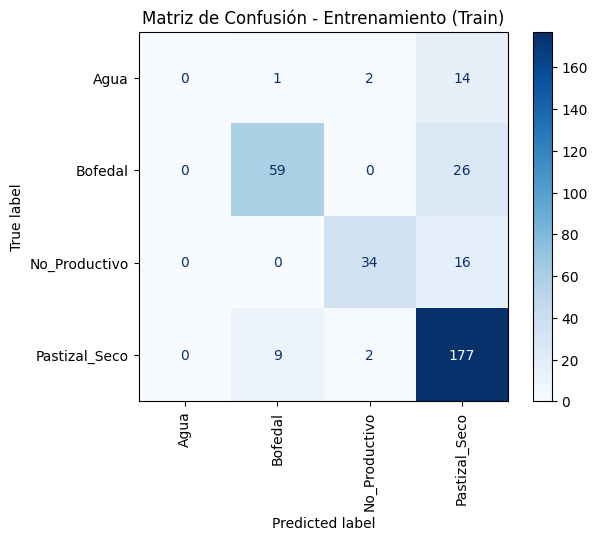



--- Métricas en el Conjunto Prueba (Test) ---
Accuracy (Exactitud): 0.7647 (76.47%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00         4
      Bofedal       0.83      0.71      0.77        21
No_Productivo       0.88      0.54      0.67        13
Pastizal_Seco       0.73      0.91      0.81        47

     accuracy                           0.76        85
    macro avg       0.61      0.54      0.56        85
 weighted avg       0.74      0.76      0.74        85


Matriz de Confusión:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


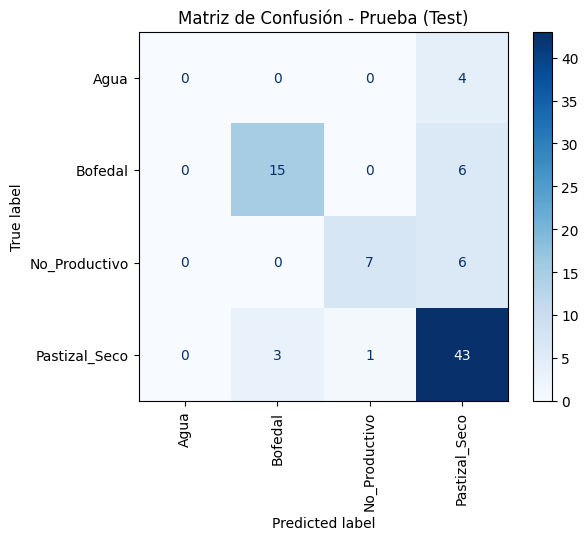

In [244]:
def metricas_clasificacion(y_true, y_pred, title):
    """
    Imprime un reporte de clasificación completo y muestra la matriz de confusión.
    """
    print(f"--- Métricas en el Conjunto {title} ---")

    # Accuracy (Exactitud): ¿Qué porcentaje de predicciones fueron correctas?
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy (Exactitud): {acc:.4f} ({acc*100:.2f}%)")
    print("\nReporte de Clasificación:")

    # Classification Report: Muestra Precision, Recall y F1-Score para CADA clase.
    # - Precision: De lo que predije como 'Bofedal', ¿cuántos acerté?
    # - Recall (Sensibilidad): De todos los 'Bofedal' reales, ¿cuántos encontré?
    # - F1-Score: El balance armónico entre Precision y Recall.
    print(classification_report(y_true, y_pred))

    print("\nMatriz de Confusión:")
    # Matriz de Confusión: Muestra visualmente qué clases se confunden entre sí.
    # Filas = Valor Real, Columnas = Valor Predicho
    try:
        ConfusionMatrixDisplay.from_predictions(
            y_true,
            y_pred,
            cmap='Blues',
            xticks_rotation='vertical'
        )
        plt.title(f"Matriz de Confusión - {title}")
        plt.show()
    except Exception as e:
        print(f"No se pudo graficar la matriz de confusión: {e}")

    print("\n" + "="*50 + "\n")

# --- Calcular y mostrar las nuevas métricas ---
metricas_clasificacion(y_train, predictions_train_svm, "Entrenamiento (Train)")
metricas_clasificacion(y_test, predictions_test_svm, "Prueba (Test)")

In [245]:
X_test_1 = pd.DataFrame(X_test, columns=X.columns)

## Decision tree regression

Iniciando la búsqueda de hiperparámetros para Decision Tree...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Búsqueda completada.


Mejores Hiperparámetros (Árbol): {'tree__criterion': 'gini', 'tree__max_depth': 5}
Mejor F1-Score (ponderado) en CV: 0.7406

--- Métricas para Decision Tree ---
--- Métricas en el Conjunto Árbol - Entrenamiento ---
Accuracy (Exactitud): 0.8529 (85.29%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       1.00      0.06      0.11        17
      Bofedal       0.93      0.80      0.86        85
No_Productivo       0.95      0.74      0.83        50
Pastizal_Seco       0.81      0.98      0.89       188

     accuracy                           0.85       340
    macro avg       0.92      0.64      0.67       340
 weighted avg       0.87      0.85      0.83       340


Matriz de Confusión:


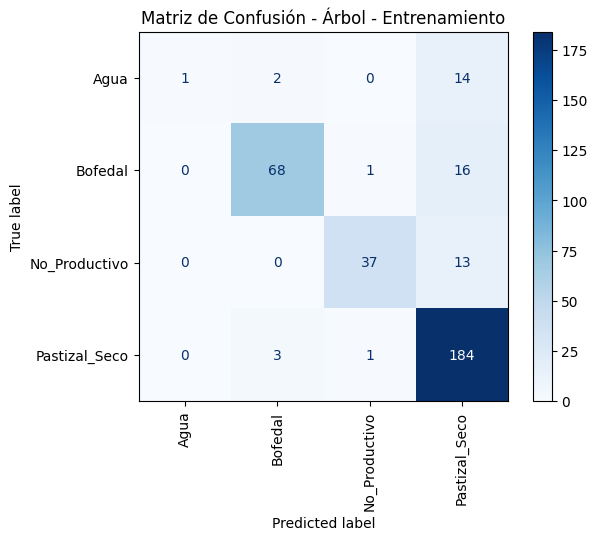



--- Métricas en el Conjunto Árbol - Prueba ---
Accuracy (Exactitud): 0.7529 (75.29%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00         4
      Bofedal       0.77      0.81      0.79        21
No_Productivo       0.75      0.46      0.57        13
Pastizal_Seco       0.76      0.87      0.81        47

     accuracy                           0.75        85
    macro avg       0.57      0.54      0.54        85
 weighted avg       0.73      0.75      0.73        85


Matriz de Confusión:


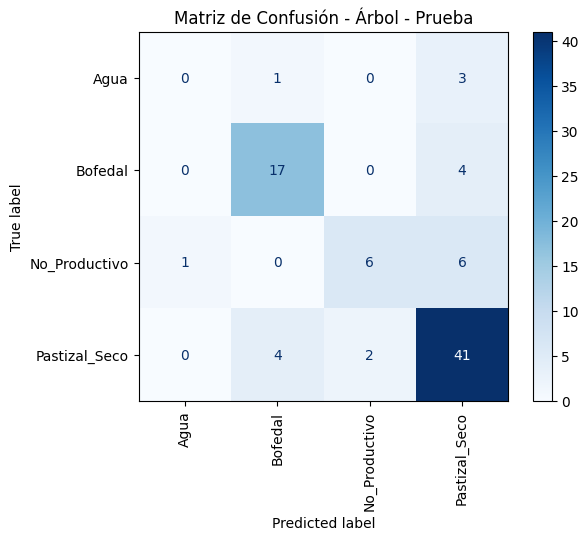




--- Importancia de Features (Decision Tree) ---
   Feature  Importancia
8    OSAVI     0.689431
2       B5     0.073387
5      B12     0.061270
9    TNDVI     0.054339
7     NDWI     0.041396
4      B11     0.036796
0       B3     0.017751
1     NDVI     0.014947
6  CIgreen     0.010683
3       B7     0.000000


In [331]:
pipe_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeClassifier(random_state=42))
])

# --- 2. Definir los Hiperparámetros a Probar ---
# 'max_depth': ¿Qué tan profundo puede crecer el árbol? (Clave para evitar sobreajuste)
# 'criterion': ¿Cómo medir la "pureza" de una división?
param_grid_tree = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [3, 5, 7, 10, None]
}

# --- 3. Configurar la Búsqueda (GridSearch) ---
# Usamos tu 'cv_estratificado' y 'scoring'
grid_search_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    cv=cv_estratificado,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# --- 4. Entrenar ---
print("Iniciando la búsqueda de hiperparámetros para Decision Tree...")
grid_search_tree.fit(X_train, y_train)
print("Búsqueda completada.")

# --- 5. Mejores Resultados ---
print("\n" + "="*50 + "\n")
print(f"Mejores Hiperparámetros (Árbol): {grid_search_tree.best_params_}")
print(f"Mejor F1-Score (ponderado) en CV: {grid_search_tree.best_score_:.4f}")
print("="*50 + "\n")

# --- 6. Obtener Predicciones ---
best_model_tree = grid_search_tree.best_estimator_
predictions_train_tree = best_model_tree.predict(X_train)
predictions_test_tree = best_model_tree.predict(X_test)

# --- 7. Evaluar (usando tu función) ---
# (Asegúrate de que la función 'metricas_clasificacion' esté definida)
print("--- Métricas para Decision Tree ---")
metricas_clasificacion(y_train, predictions_train_tree, "Árbol - Entrenamiento")
metricas_clasificacion(y_test, predictions_test_tree, "Árbol - Prueba")

# --- 8. (BONUS) Importancia de Features (Fácil) ---
print("\n--- Importancia de Features (Decision Tree) ---")
# Extraemos el árbol entrenado del pipeline
importances_tree = best_model_tree.named_steps['tree'].feature_importances_

# Creamos un DataFrame para verlo bonito
df_imp_tree = pd.DataFrame({
    'Feature': feature_names,
    'Importancia': importances_tree
}).sort_values(by='Importancia', ascending=False)

print(df_imp_tree.head(10))

## Random Forest



Iniciando la búsqueda de hiperparámetros para Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Búsqueda completada.


Mejores Hiperparámetros (Random Forest): {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__n_estimators': 100}
Mejor F1-Score (ponderado) en CV: 0.7619

--- Métricas para Random Forest ---
--- Métricas en el Conjunto Random Forest - Entrenamiento ---
Accuracy (Exactitud): 1.0000 (100.00%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       1.00      1.00      1.00        17
      Bofedal       1.00      1.00      1.00        85
No_Productivo       1.00      1.00      1.00        50
Pastizal_Seco       1.00      1.00      1.00       188

     accuracy                           1.00       340
    macro avg       1.00      1.00      1.00       340
 weighted avg       1.00      1.00      1.00       340


Matriz de Confusión:


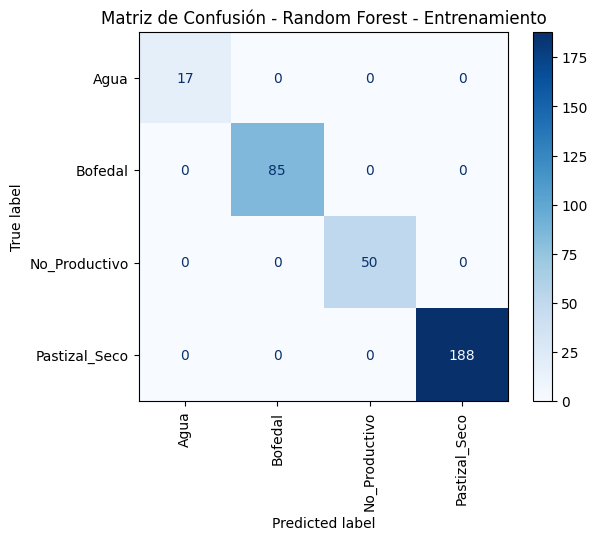



--- Métricas en el Conjunto Random Forest - Prueba ---
Accuracy (Exactitud): 0.7647 (76.47%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00         4
      Bofedal       0.71      0.71      0.71        21
No_Productivo       0.90      0.69      0.78        13
Pastizal_Seco       0.79      0.87      0.83        47

     accuracy                           0.76        85
    macro avg       0.60      0.57      0.58        85
 weighted avg       0.75      0.76      0.75        85


Matriz de Confusión:


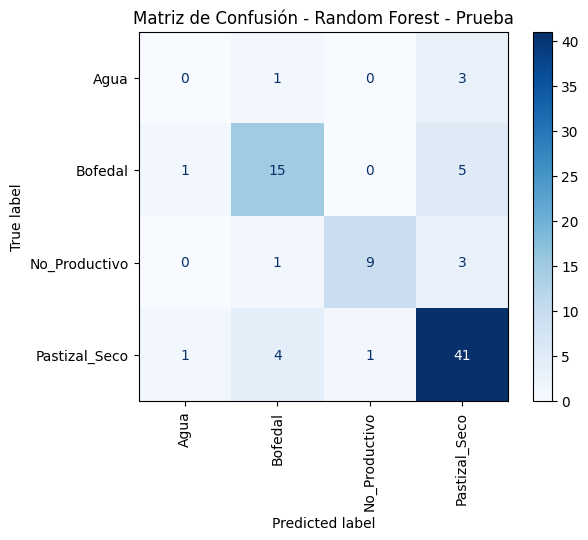

In [249]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# --- 2. Definir los Hiperparámetros a Probar ---
# 'n_estimators': ¿Cuántos árboles construir?
# 'max_depth': Profundidad máxima de cada árbol.
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200], # Número de árboles
    'rf__max_depth': [5, 10, None],     # Profundidad
    'rf__max_features': ['sqrt', 'log2'] # Cuántas features mirar en cada división
}

# --- 3. Configurar la Búsqueda (GridSearch) ---
grid_search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv_estratificado,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# --- 4. Entrenar ---
print("Iniciando la búsqueda de hiperparámetros para Random Forest...")
grid_search_rf.fit(X_train, y_train)
print("Búsqueda completada.")

# --- 5. Mejores Resultados ---
print("\n" + "="*50 + "\n")
print(f"Mejores Hiperparámetros (Random Forest): {grid_search_rf.best_params_}")
print(f"Mejor F1-Score (ponderado) en CV: {grid_search_rf.best_score_:.4f}")
print("="*50 + "\n")

# --- 6. Obtener Predicciones ---
best_model_rf = grid_search_rf.best_estimator_
predictions_train_rf = best_model_rf.predict(X_train)
predictions_test_rf = best_model_rf.predict(X_test)

# --- 7. Evaluar (usando tu función) ---
print("--- Métricas para Random Forest ---")
metricas_clasificacion(y_train, predictions_train_rf, "Random Forest - Entrenamiento")
metricas_clasificacion(y_test, predictions_test_rf, "Random Forest - Prueba")

# --- 8. (BONUS) Importancia de Features (Fácil) ---
print("\n--- Importancia de Features (Random Forest) ---")
# Extraemos el modelo entrenado del pipeline
importances_rf = best_model_rf.named_steps['rf'].feature_importances_

# Creamos un DataFrame para verlo bonito
df_imp_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importancia': importances_rf
}).sort_values(by='Importancia', ascending=False)

print(df_imp_rf.head(10))

## LASSO

Iniciando la búsqueda de hiperparámetros para Regresión Logística (Lasso)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

Búsqueda completada.


Mejores Hiperparámetros (Lasso): {'lasso__C': 100}
Mejor F1-Score (ponderado) en CV: 0.7454

--- Métricas para Regresión Logística (Lasso) ---
--- Métricas en el Conjunto Lasso - Entrenamiento ---
Accuracy (Exactitud): 0.7824 (78.24%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00        17
      Bofedal       0.81      0.68      0.74        85
No_Productivo       0.88      0.70      0.78        50
Pastizal_Seco       0.76      0.92      0.83       188

     accuracy                           0.78       340
    macro avg       0.61      0.58      0.59       340
 weighted avg       0.75      0.78      0.76       340


Matriz de Confusión:


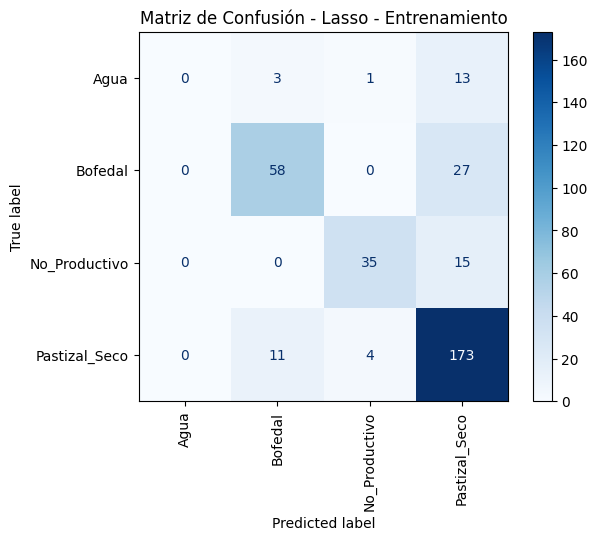



--- Métricas en el Conjunto Lasso - Prueba ---
Accuracy (Exactitud): 0.7647 (76.47%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00         4
      Bofedal       0.79      0.71      0.75        21
No_Productivo       0.78      0.54      0.64        13
Pastizal_Seco       0.75      0.91      0.83        47

     accuracy                           0.76        85
    macro avg       0.58      0.54      0.55        85
 weighted avg       0.73      0.76      0.74        85


Matriz de Confusión:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


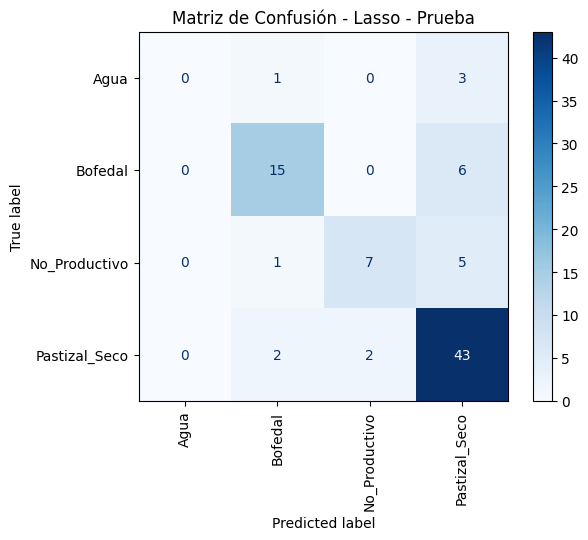




--- Coeficientes de Features (Lasso) ---
   Feature  Importancia (Clase: Agua)
3       B7                   1.575617
8    OSAVI                   0.917282
1     NDVI                   0.831429
0       B3                   0.460668
5      B12                  -0.067132
4      B11                  -0.457905
2       B5                  -1.483732
9    TNDVI                  -2.036586
7     NDWI                  -4.004851
6  CIgreen                  -5.097851


In [361]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, multi_class='auto'))
])

# --- 2. Definir los Hiperparámetros a Probar ---
# 'C': Es la *inversa* de la fuerza de regularización.
# Un 'C' pequeño = Más penalización (más features irán a cero).
param_grid_lasso = {
    'lasso__C': [0.01, 0.1, 1, 10, 100]
}

# --- 3. Configurar la Búsqueda (GridSearch) ---
grid_search_lasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid_lasso,
    cv=cv_estratificado,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# --- 4. Entrenar ---
print("Iniciando la búsqueda de hiperparámetros para Regresión Logística (Lasso)...")
grid_search_lasso.fit(X_train, y_train)
print("Búsqueda completada.")

# --- 5. Mejores Resultados ---
print("\n" + "="*50 + "\n")
print(f"Mejores Hiperparámetros (Lasso): {grid_search_lasso.best_params_}")
print(f"Mejor F1-Score (ponderado) en CV: {grid_search_lasso.best_score_:.4f}")
print("="*50 + "\n")

# --- 6. Obtener Predicciones ---
best_model_lasso = grid_search_lasso.best_estimator_
predictions_train_lasso = best_model_lasso.predict(X_train)
predictions_test_lasso = best_model_lasso.predict(X_test)

# --- 7. Evaluar (usando tu función) ---
print("--- Métricas para Regresión Logística (Lasso) ---")
metricas_clasificacion(y_train, predictions_train_lasso, "Lasso - Entrenamiento")
metricas_clasificacion(y_test, predictions_test_lasso, "Lasso - Prueba")

# --- 8. (BONUS) Importancia de Features (Coeficientes) ---
print("\n--- Coeficientes de Features (Lasso) ---")
# Extraemos los coeficientes del modelo. Lasso pone 0 a las features inútiles.
# Como es multi-clase, tenemos un set de coeficientes por cada clase.
coeficientes_lasso = best_model_lasso.named_steps['lasso'].coef_

# Mostramos los coeficientes para la primera clase (ej: 'Agua')
df_imp_lasso = pd.DataFrame({
    'Feature': feature_names,
    f'Importancia (Clase: {best_model_lasso.classes_[0]})': coeficientes_lasso[0]
}).sort_values(by=f'Importancia (Clase: {best_model_lasso.classes_[0]})', ascending=False)

print(df_imp_lasso.head(10))

## Ride

Iniciando la búsqueda de hiperparámetros para Regresión Logística (Ridge)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

Búsqueda completada.


Mejores Hiperparámetros (Ridge): {'ridge__C': 1}
Mejor F1-Score (ponderado) en CV: 0.7535

--- Métricas para Regresión Logística (Ridge) ---
--- Métricas en el Conjunto Ridge - Entrenamiento ---
Accuracy (Exactitud): 0.7882 (78.82%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00        17
      Bofedal       0.83      0.69      0.76        85
No_Productivo       0.83      0.70      0.76        50
Pastizal_Seco       0.77      0.93      0.84       188

     accuracy                           0.79       340
    macro avg       0.61      0.58      0.59       340
 weighted avg       0.75      0.79      0.76       340


Matriz de Confusión:


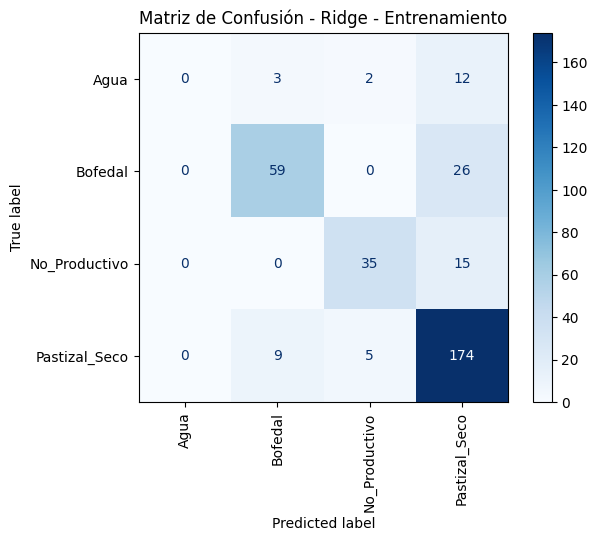



--- Métricas en el Conjunto Ridge - Prueba ---
Accuracy (Exactitud): 0.7529 (75.29%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00         4
      Bofedal       0.88      0.67      0.76        21
No_Productivo       0.78      0.54      0.64        13
Pastizal_Seco       0.72      0.91      0.80        47

     accuracy                           0.75        85
    macro avg       0.59      0.53      0.55        85
 weighted avg       0.73      0.75      0.73        85


Matriz de Confusión:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


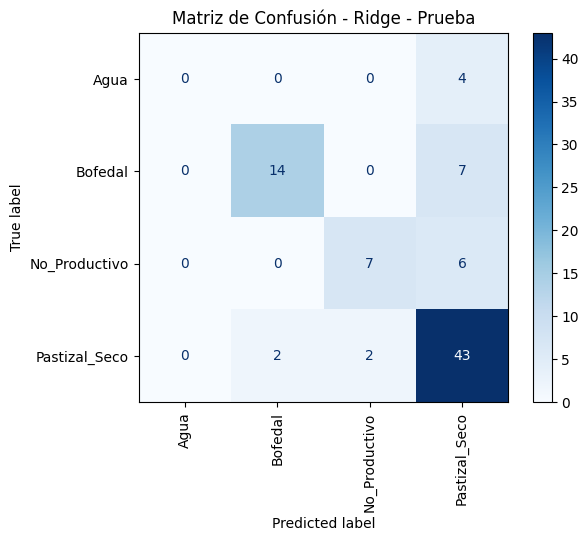




--- Importancia de Features (Ridge) ---
   Feature  Importancia (magnitud media)
4      B11                      0.908508
9    TNDVI                      0.599654
1     NDVI                      0.464636
8    OSAVI                      0.464631
5      B12                      0.455892
0       B3                      0.366863
6  CIgreen                      0.338598
2       B5                      0.283000
7     NDWI                      0.196186
3       B7                      0.117620


In [362]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', LogisticRegression(penalty='l2', solver='lbfgs', random_state=42, multi_class='auto'))
])

# --- 2. Definir los Hiperparámetros a Probar ---
# 'C': Inversa de la fuerza de regularización.
param_grid_ridge = {
    'ridge__C': [0.01, 0.1, 1, 10, 100]
}

# --- 3. Configurar la Búsqueda (GridSearch) ---
grid_search_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    cv=cv_estratificado,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# --- 4. Entrenar ---
print("Iniciando la búsqueda de hiperparámetros para Regresión Logística (Ridge)...")
grid_search_ridge.fit(X_train, y_train)
print("Búsqueda completada.")

# --- 5. Mejores Resultados ---
print("\n" + "="*50 + "\n")
print(f"Mejores Hiperparámetros (Ridge): {grid_search_ridge.best_params_}")
print(f"Mejor F1-Score (ponderado) en CV: {grid_search_ridge.best_score_:.4f}")
print("="*50 + "\n")

# --- 6. Obtener Predicciones ---
best_model_ridge = grid_search_ridge.best_estimator_
predictions_train_ridge = best_model_ridge.predict(X_train)
predictions_test_ridge = best_model_ridge.predict(X_test)

# --- 7. Evaluar (usando tu función) ---
print("--- Métricas para Regresión Logística (Ridge) ---")
metricas_clasificacion(y_train, predictions_train_ridge, "Ridge - Entrenamiento")
metricas_clasificacion(y_test, predictions_test_ridge, "Ridge - Prueba")


# --- 8. (BONUS) Importancia de Features (Ridge) ---
print("\n--- Importancia de Features (Ridge) ---")

# Extraemos el modelo Ridge entrenado del pipeline
ridge_model = best_model_ridge.named_steps['ridge']

# Obtenemos los coeficientes
coeficientes_ridge = ridge_model.coef_

# Calculamos la importancia global promediando la magnitud (abs)
# a través de todas las clases (axis=0)
importances_ridge = np.mean(np.abs(coeficientes_ridge), axis=0)

# Creamos un DataFrame para verlo bonito
df_imp_ridge = pd.DataFrame({
    'Feature': feature_names,
    'Importancia (magnitud media)': importances_ridge
}).sort_values(by='Importancia (magnitud media)', ascending=False)

print(df_imp_ridge.head(10))

In [252]:
unique, counts = np.unique(y_test_xgb, return_counts=True)
dict(zip(unique, counts))

{np.int64(0): np.int64(4),
 np.int64(1): np.int64(21),
 np.int64(2): np.int64(13),
 np.int64(3): np.int64(47)}

In [253]:
y_test.value_counts()

,count
GRUPO_ML,
Pastizal_Seco,47
Bofedal,21
No_Productivo,13
Agua,4


## XGboost


Iniciando la búsqueda de hiperparámetros para XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Búsqueda completada.


Mejores Hiperparámetros (XGBoost): {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Mejor F1-Score (ponderado) en CV: 0.7514

--- Métricas para XGBoost ---
--- Métricas en el Conjunto XGBoost - Entrenamiento ---
Accuracy (Exactitud): 0.9441 (94.41%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       1.00      0.59      0.74        17
      Bofedal       0.99      0.94      0.96        85
No_Productivo       0.98      0.88      0.93        50
Pastizal_Seco       0.92      0.99      0.95       188

     accuracy                           0.94       340
    macro avg       0.97      0.85      0.90       340
 weighted avg       0.95      0.94      0.94       340


Matriz de Confusión:


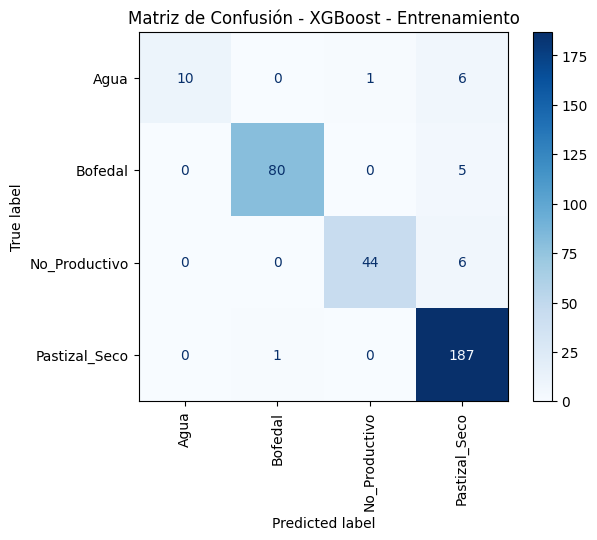



--- Métricas en el Conjunto XGBoost - Prueba ---
Accuracy (Exactitud): 0.7765 (77.65%)

Reporte de Clasificación:
               precision    recall  f1-score   support

         Agua       0.00      0.00      0.00         4
      Bofedal       0.73      0.76      0.74        21
No_Productivo       0.82      0.69      0.75        13
Pastizal_Seco       0.79      0.87      0.83        47

     accuracy                           0.78        85
    macro avg       0.58      0.58      0.58        85
 weighted avg       0.74      0.78      0.76        85


Matriz de Confusión:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


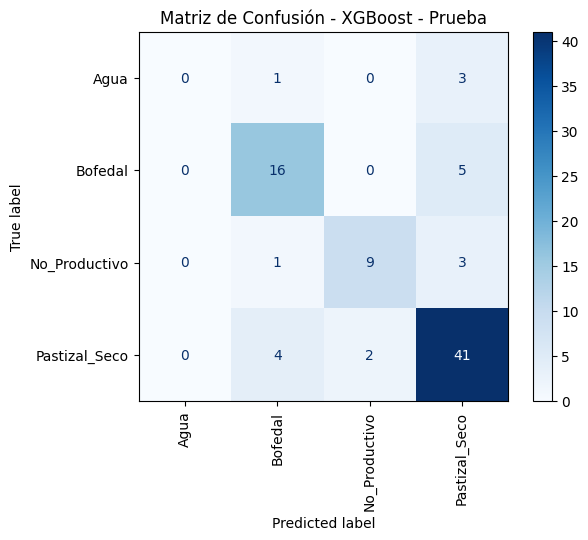




--- Importancia de Features (XGBoost) ---
   Feature  Importancia
1     NDVI     0.391481
2       B5     0.107000
6  CIgreen     0.105938
4      B11     0.087014
3       B7     0.084685
5      B12     0.082113
7     NDWI     0.075293
0       B3     0.066476
8    OSAVI     0.000000
9    TNDVI     0.000000


In [254]:
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)
# Guardamos las clases para después: le.classes_ -> ['Agua', 'Bofedal', ...]

# --- 1. Definir el Pipeline para XGBoost ---
# El escalador no es estrictamente necesario, pero lo mantenemos
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(objective='multi:softmax', # Objetivo: Clasificación Multi-Clase
                           num_class=4,             # Le decimos que hay 4 clases
                           random_state=42,
                           eval_metric='mlogloss'))
])

# --- 2. Definir los Hiperparámetros a Probar ---
# (Este grid es pequeño para que corra rápido)
param_grid_xgb = {
    'xgb__n_estimators': [50, 100],      # Número de árboles
    'xgb__learning_rate': [0.1, 0.3],     # Tasa de aprendizaje
    'xgb__max_depth': [3, 5]              # Profundidad de los árboles
}

# --- 3. Configurar la Búsqueda (GridSearch) ---
grid_search_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv_estratificado,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# --- 4. Entrenar ---
print("Iniciando la búsqueda de hiperparámetros para XGBoost...")
grid_search_xgb.fit(X_train, y_train_xgb) # USAMOS y_train_xgb (numérico)
print("Búsqueda completada.")

# --- 5. Mejores Resultados ---
print("\n" + "="*50 + "\n")
print(f"Mejores Hiperparámetros (XGBoost): {grid_search_xgb.best_params_}")
print(f"Mejor F1-Score (ponderado) en CV: {grid_search_xgb.best_score_:.4f}")
print("="*50 + "\n")

# --- 6. Obtener Predicciones ---
best_model_xgb = grid_search_xgb.best_estimator_
predictions_train_xgb_num = best_model_xgb.predict(X_train)
predictions_test_xgb_num = best_model_xgb.predict(X_test)

# 7. REVERTIR PREDICCIONES A TEXTO (para la función de métricas)
predictions_train_xgb_txt = le.inverse_transform(predictions_train_xgb_num)
predictions_test_xgb_txt = le.inverse_transform(predictions_test_xgb_num)

# --- 8. Evaluar (usando tu función y 'y' original de texto) ---
print("--- Métricas para XGBoost ---")
metricas_clasificacion(y_train, predictions_train_xgb_txt, "XGBoost - Entrenamiento")
metricas_clasificacion(y_test, predictions_test_xgb_txt, "XGBoost - Prueba")

# --- 9. (BONUS) Importancia de Features (XGBoost) ---
print("\n--- Importancia de Features (XGBoost) ---")
importances_xgb = best_model_xgb.named_steps['xgb'].feature_importances_

df_imp_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importancia': importances_xgb
}).sort_values(by='Importancia', ascending=False)

print(df_imp_xgb.head(10))

## Resultados

In [255]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def obtener_metricas_clasificacion(y_train_true, y_train_pred, y_test_true, y_test_pred):
    """
    Calcula un resumen de métricas de clasificación para train y test.
    Usa 'weighted' para promediar en problemas multi-clase desbalanceados.
    """
    # --- Métricas de Train ---
    acc_train = accuracy_score(y_train_true, y_train_pred)
    # F1-score es la métrica más importante para clases desbalanceadas
    f1_train = f1_score(y_train_true, y_train_pred, average='weighted')
    precision_train = precision_score(y_train_true, y_train_pred, average='weighted', zero_division=0)
    recall_train = recall_score(y_train_true, y_train_pred, average='weighted', zero_division=0)

    # --- Métricas de Test ---
    acc_test = accuracy_score(y_test_true, y_test_pred)
    f1_test = f1_score(y_test_true, y_test_pred, average='weighted')
    precision_test = precision_score(y_test_true, y_test_pred, average='weighted', zero_division=0)
    recall_test = recall_score(y_test_true, y_test_pred, average='weighted', zero_division=0)

    # Devuelve una tupla con todas las métricas
    return (
        acc_train, f1_train, precision_train, recall_train,
        acc_test, f1_test, precision_test, recall_test
    )

# --- 1. Define los nombres de las columnas (Métricas de Clasificación) ---
column_names_clasif = [
    'Accuracy_Train', 'F1_Train (w)', 'Precision_Train (w)', 'Recall_Train (w)',
    'Accuracy_Test', 'F1_Test (w)', 'Precision_Test (w)', 'Recall_Test (w)'
]

# --- 2. Define los nombres de tus modelos (las filas) ---
model_names = [
    'SVM (SVC)',
    'Decision Tree',
    'Random Forest',
    'Lasso (LogReg)',
    'Ridge (LogReg)',
    'XGBoost'
]

# --- 3. Recolecta los resultados de cada modelo ---
# (Asegúrate de haber corrido todos los modelos y tener estas variables)
# (Recuerda usar las predicciones de XGBoost en TEXTO: 'predictions_train_xgb_txt')
model_results_clasif = [
    obtener_metricas_clasificacion(y_train, predictions_train_svm, y_test, predictions_test_svm),
    obtener_metricas_clasificacion(y_train, predictions_train_tree, y_test, predictions_test_tree),
    obtener_metricas_clasificacion(y_train, predictions_train_rf, y_test, predictions_test_rf),
    obtener_metricas_clasificacion(y_train, predictions_train_lasso, y_test, predictions_test_lasso),
    obtener_metricas_clasificacion(y_train, predictions_train_ridge, y_test, predictions_test_ridge),
    obtener_metricas_clasificacion(y_train, predictions_train_xgb_txt, y_test, predictions_test_xgb_txt)
]

# --- 4. Crea el DataFrame 📊 ---
df_resultados_clasif = pd.DataFrame(data=model_results_clasif, index=model_names, columns=column_names_clasif)

# Opcional: Redondear y ordenar por la mejor métrica de Test (F1-Score)
df_resultados_clasif = df_resultados_clasif.round(4)
df_resultados_clasif = df_resultados_clasif.sort_values(by='F1_Test (w)', ascending=False)

# --- 5. Muestra la tabla ---
print("--- Tabla Comparativa de Modelos de Clasificación ---")
df_resultados_clasif

--- Tabla Comparativa de Modelos de Clasificación ---


,Accuracy_Train,F1_Train (w),Precision_Train (w),Recall_Train (w),Accuracy_Test,F1_Test (w),Precision_Test (w),Recall_Test (w)
XGBoost,0.9441,0.9418,0.9476,0.9441,0.7765,0.7566,0.7408,0.7765
Random Forest,1.0000,1.0000,1.0000,1.0000,0.7647,0.7542,0.7501,0.7647
SVM (SVC),0.7941,0.7701,0.7654,0.7941,0.7647,0.7406,0.7427,0.7647
Lasso (LogReg),0.7824,0.7590,0.7496,0.7824,0.7647,0.7399,0.7311,0.7647
Decision Tree,0.8529,0.8333,0.8706,0.8529,0.7529,0.7317,0.7254,0.7529
Ridge (LogReg),0.7882,0.7647,0.7541,0.7882,0.7529,0.7287,0.7314,0.7529


# mapa tambokarkas

"B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"

variables = ['mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration',
       'clip_CIgreen_10m_tamb', 'clip_NDWI_10m_tamb', 'clip_OSAVI_10m_tamb',
       'clip_TNDVI_10m_tamb']

In [348]:
# --- Configuración ---
ruta_original = f"{PATH}/TAMBOKARKAS/Data_Final_Tambo/Cobertura/Bandas_F.tif"
ruta_salida_subset = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices.tif"

# 1. Define los NÚMEROS de las bandas que quieres MANTENER
# (Recuerda que rasterio empieza a contar desde 1)
bandas_a_mantener = [1, 2, 3, 4, 5, 6, 12, 13, 14, 15] # Mantenemos solo los 9 índices
# bandas_a_mantener = [10, 11, 12, 13, 14] # Si quisieras solo las 5 bandas crudas

print(f"Abriendo el archivo original: {ruta_original}")
with rasterio.open(ruta_original) as src:

    # 2. Lee solo los datos de las bandas que quieres
    data_subset = src.read(bandas_a_mantener)

    # 3. Obtén los nombres de esas bandas (para mantenerlos)
    nombres_originales = src.descriptions
    nombres_subset = [nombres_originales[i - 1] for i in bandas_a_mantener]

    # 4. Copia el perfil (metadatos) y actualízalo
    profile = src.profile
    profile.update(
        count=len(bandas_a_mantener), # Actualiza el número de bandas
        compress='lzw'                 # (Opcional, pero recomendado)
    )

    print(f"Creando el nuevo archivo con {len(bandas_a_mantener)} bandas: {ruta_salida_subset}")

    # 5. Escribe el nuevo archivo TIF
    with rasterio.open(ruta_salida_subset, 'w', **profile) as dst:
        # Escribe los datos
        dst.write(data_subset)

        # Asigna los nombres correctos al nuevo archivo
        for i, nombre in enumerate(nombres_subset):
            dst.set_band_description(i + 1, nombre)

print("¡Proceso de 'borrado' (subconjunto) completado!")

Abriendo el archivo original: /content/drive/MyDrive/DATATHON CIP 2025/TAMBOKARKAS/Data_Final_Tambo/Cobertura/Bandas_F.tif
Creando el nuevo archivo con 10 bandas: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices.tif
¡Proceso de 'borrado' (subconjunto) completado!


In [349]:
# --- Configuración ---
ruta_original = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices.tif"
ruta_salida_nombres = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices_nombrados.tif"

# 1. Define la LISTA COMPLETA de nuevos nombres
# (Debe tener EXACTAMENTE el mismo número de bandas que el original)
nuevos_nombres = [
   "B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"
]

print(f"Abriendo el archivo original: {ruta_original}")
with rasterio.open(ruta_original) as src:

    # Verifica que la lista de nombres coincida
    if len(nuevos_nombres) != src.count:
        print(f"Error: El TIF tiene {src.count} bandas, pero diste {len(nuevos_nombres)} nombres.")
    else:
        # 2. Lee TODOS los datos
        data = src.read()

        # 3. Copia el perfil (metadatos)
        profile = src.profile
        profile.update(compress='lzw') # (Opcional)

        print(f"Creando copia con nombres nuevos: {ruta_salida_nombres}")

        # 4. Escribe el nuevo archivo
        with rasterio.open(ruta_salida_nombres, 'w', **profile) as dst:
            dst.write(data)

            # 5. Asigna los nuevos nombres
            for i, nombre in enumerate(nuevos_nombres):
                dst.set_band_description(i + 1, nombre)

print("¡Proceso de renombrado completado!")

Abriendo el archivo original: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices.tif
Creando copia con nombres nuevos: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices_nombrados.tif
¡Proceso de renombrado completado!


In [350]:
ruta_a_mi_tiff = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices_nombrados.tif"

print(f"Calculando estadísticas (estilo .describe()) para: {ruta_a_mi_tiff}\n")

# Diccionario para guardar los resultados
all_stats = {}

try:
    with rasterio.open(ruta_a_mi_tiff) as src:

        # Obtener los nombres de las bandas
        nombres_bandas = src.descriptions or [f'Banda_{i+1}' for i in range(src.count)]
        nodata_val = src.nodata

        # Iterar sobre cada banda
        for i, nombre in enumerate(nombres_bandas):
            banda_num = i + 1

            # Leer la banda y enmascarar NoData
            data = src.read(banda_num).astype(float)
            if nodata_val is not None:
                data[data == nodata_val] = np.nan

            # Calcular las estadísticas (ignorando NaN)
            stats = {
                'count': np.count_nonzero(~np.isnan(data)), # Conteo de píxeles válidos
                'mean': np.nanmean(data),
                'std': np.nanstd(data),
                'min': np.nanmin(data),
                '25%': np.nanpercentile(data, 25),
                '50%': np.nanpercentile(data, 50),
                '75%': np.nanpercentile(data, 75),
                'max': np.nanmax(data)
            }

            # Guardar las estadísticas de esta banda
            all_stats[nombre] = stats

    # --- 7. Convertir el diccionario a un DataFrame de pandas ---
    # .from_dict() crea el DataFrame con las bandas como columnas
    df_stats = pd.DataFrame.from_dict(all_stats)

    # Imprimir la tabla redondeada
    print(df_stats.round(4))

except Exception as e:
    print(f"Error al procesar el archivo: {e}")

Calculando estadísticas (estilo .describe()) para: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices_nombrados.tif

               B3        NDVI          B5          B7         B11         B12  \
count  48825.0000  48811.0000  48068.0000  48068.0000  48068.0000  48068.0000   
mean       0.1194      0.1896   1918.0902   2388.1158   3945.5967   2783.8313   
std        0.0244      0.0458    232.3426    300.1435    358.8607    270.5049   
min        0.0107     -0.0391    958.0866   1132.6597   2556.0586   1576.2863   
25%        0.1078      0.1658   1789.0090   2229.9934   3732.3691   2631.2846   
50%        0.1196      0.1839   1943.9260   2407.7805   4019.1824   2812.8558   
75%        0.1306      0.2025   2070.9615   2570.4926   4210.4087   2957.7664   
max        0.4788      0.5628   2707.0906   3597.9019   4888.2202   3972.4670   

          CIgreen        NDWI       OSAVI       TNDVI  
count  52297.0000  52297.0000  52297.0000  52271.0000  


In [259]:
df_stats

,B3,NDVI,B5,B7,B11,B12,CIgreen,NDWI,OSAVI,TNDVI
count,48825.000000,48811.000000,48068.000000,48068.000000,48068.000000,48068.000000,52297.000000,52297.000000,52297.000000,52271.000000
mean,0.119399,0.189579,1918.090159,2388.115801,3945.596741,2783.831288,1.464548,-0.397033,0.165421,0.831237
std,0.024358,0.045774,232.342629,300.143501,358.860675,270.504927,0.919170,0.094812,0.057504,0.032208
min,0.010745,-0.039054,958.086609,1132.659668,2556.058594,1576.286255,0.098322,-0.834071,-0.211002,0.547038
25%,0.107808,0.165789,1789.009003,2229.993408,3732.369141,2631.284607,1.061386,-0.421045,0.137990,0.814999
50%,0.119602,0.183855,1943.926025,2407.780518,4019.182373,2812.855835,1.219345,-0.377591,0.155302,0.826438
75%,0.130584,0.202484,2070.961487,2570.492615,4210.408691,2957.766418,1.465335,-0.345561,0.174948,0.839093
max,0.478796,0.562809,2707.090576,3597.901855,4888.220215,3972.467041,10.630057,-0.032935,1.057742,1.183889


In [261]:
gdf_puntos_1.describe()

,NDVI,GNDVI,CIgreen,TNDVI,OSAVI,NDWI,NDSVI,NDPI,NDGI,B3,B5,B7,B11,B12
count,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000
mean,0.233992,0.336587,1.042447,0.855829,0.271419,-0.336587,0.399251,-0.399251,-0.111513,0.121631,1783.257227,2303.012325,3538.823922,2414.356078
std,0.068955,0.062079,0.301852,0.039392,0.079984,0.062079,0.062798,0.062798,0.027667,0.021031,291.725246,364.049740,430.524741,314.904460
min,0.082901,0.145517,0.340598,0.763479,0.096162,-0.570706,0.158535,-0.574410,-0.222930,0.075400,1089.000000,1379.000000,2222.000000,1541.000000
25%,0.192443,0.305575,0.880081,0.832132,0.223227,-0.369014,0.368240,-0.435939,-0.126200,0.106400,1588.000000,2059.000000,3274.000000,2220.000000
50%,0.221083,0.335782,1.011058,0.849166,0.256446,-0.335782,0.406449,-0.406449,-0.109890,0.120100,1764.000000,2284.000000,3610.000000,2418.000000
75%,0.263135,0.369014,1.169643,0.873576,0.305225,-0.305575,0.435939,-0.368240,-0.094845,0.133400,1966.000000,2572.000000,3839.000000,2631.000000
max,0.549430,0.570706,2.658810,1.024417,0.637314,-0.145517,0.574410,-0.158535,-0.004479,0.202200,3211.500000,3826.000000,4646.000000,3295.000000


In [262]:
variables = ["B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"]

## PREDICT

In [351]:
# ================================================================

# 6️⃣ APLICAR MODELO A RASTER MULTIBANDA

# ================================================================

ruta_tif = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Tambo_indices_nombrados.tif"

with rasterio.open(ruta_tif) as src:
    img = src.read()  # (bandas, filas, columnas)
    profile = src.profile # Guarda el perfil para exportar después

print(f"\nBandas encontradas en el raster: {img.shape[0]}")

if img.shape[0] < len(variables):
    raise ValueError("El raster no contiene todas las bandas esperadas.")

# 1. PREPARAR DATOS
# ----------------------------------------------------------------
# Reorganizar a (píxeles, bandas)
n_bands, n_rows, n_cols = img.shape
pixels = img.reshape(n_bands, -1).T
X_raster = pd.DataFrame(pixels, columns=variables)

# Reemplazar infinitos por NaN
X_raster.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. SEPARAR PÍXELES VÁLIDOS Y NULOS
# ----------------------------------------------------------------
# Crear una máscara booleana: True para filas sin ningún NaN
valid_pixels_mask = ~X_raster.isnull().any(axis=1)

# Crear el DataFrame solo con los datos válidos que se procesarán
X_raster_valid = X_raster[valid_pixels_mask]


Bandas encontradas en el raster: 10


In [353]:
# 3. APLICAR MODELO (SOLO A DATOS VÁLIDOS)
# ----------------------------------------------------------------

# Crear un array para el resultado final, inicializado con NaN
final_prediction = np.full(X_raster.shape[0], np.nan)

# Proceder solo si hay píxeles válidos que procesar
if not X_raster_valid.empty:
    # Estandarizar únicamente los datos válidos
    X_raster_valid_scaled = scaler.transform(X_raster_valid)

    # Predecir sobre los datos estandarizados (ESTO DEVUELVE STRINGS)
    predictions_str = best_model_tree.predict(X_raster_valid_scaled)

    # ========================== INICIO DE LA CORRECCIÓN ==========================

    # 1. Crear un mapa para "traducir" de string (texto) a int (número)
    #    Estos números (1, 2, 3, 4) serán los valores de tu raster final.
    mapa_str_a_int = {
        'Pastizal_Seco': 1,
        'Bofedal': 2,
        'No_Productivo': 3,
        'Agua': 4
    }

    # 2. Aplicar el mapa. Usamos pd.Series().map() que es muy rápido
    #    El resultado es un array de números (ej: [1, 2, 1, 3, 4, ...])
    predictions_int = pd.Series(predictions_str).map(mapa_str_a_int).to_numpy()

    # 3. Insertar las predicciones numéricas (int) en el array de floats
    #    (Esto funciona porque un int SÍ se puede guardar en un array float)
    final_prediction[valid_pixels_mask] = predictions_int

    # =========================== FIN DE LA CORRECCIÓN ============================

# 4. RECONSTRUIR EL RASTER DE SALIDA
# ----------------------------------------------------------------
# Reconvertir el vector de predicciones a su forma matricial (filas, columnas)
# Este array todavía es de tipo 'float' y tiene 'NaN's
prediction_reshaped = final_prediction.reshape(n_rows, n_cols)

print("\nProceso de predicción completado.")
print(f"Píxeles procesados: {len(X_raster_valid)}")
print(f"Píxeles con NaN (ignorados): {np.isnan(prediction_reshaped).sum()}")


# 5. EXPORTAR EL RASTER DE CLASIFICACIÓN FINAL
# ----------------------------------------------------------------
# Los mapas de clasificación deben ser enteros (int), no flotantes (float).
# Vamos a convertir los NaN a un valor 'nodata' (ej: 0) y cambiar el tipo.
nodata_value = -1 # Valor para los píxeles NaN (fondo)
prediction_final = np.nan_to_num(prediction_reshaped, nan=nodata_value).astype(np.int16)

# Actualizar el perfil (metadatos) del TIF de salida
profile.update(
    dtype=np.int16,  # Tipo de dato entero
    count=1,         # El TIF de salida solo tiene 1 banda
    nodata=nodata_value # Indicar cuál es el valor 'sin datos'
)

# Definir la ruta de salida
ruta_salida_tif = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Clasificacion_Ridge.tif"

# Escribir el archivo
with rasterio.open(ruta_salida_tif, 'w', **profile) as dst:
    dst.write(prediction_final, 1) # Escribir los datos en la banda 1

print(f"\n¡Mapa de clasificación guardado exitosamente en:")
print(ruta_salida_tif)


Proceso de predicción completado.
Píxeles procesados: 48046
Píxeles con NaN (ignorados): 51614

¡Mapa de clasificación guardado exitosamente en:
/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Clasificacion_Ridge.tif


In [354]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS

# --- Configuración ---
# 1. El TIF que acabas de guardar (probablemente en 4326)
ruta_original = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Clasificacion_Ridge.tif"
# 2. El nombre del nuevo TIF que vamos a crear
ruta_utm_32719 = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Clasificacion_Ridge_UTM.tif"
# 3. El CRS de destino que pediste
target_crs = CRS.from_epsg(32719)

print(f"Reproyectando {ruta_original} a EPSG:32719...")

# Abrir el TIF original
with rasterio.open(ruta_original) as src:
    print(f"CRS original: {src.crs}")

    # Calcular la transformación y dimensiones para el nuevo CRS
    transform, width, height = calculate_default_transform(
        src.crs, target_crs, src.width, src.height, *src.bounds)

    # Copiar los metadatos y actualizarlos
    profile = src.profile
    profile.update({
        'crs': target_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    # Escribir el nuevo archivo TIF reproyectado
    with rasterio.open(ruta_utm_32719, 'w', **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest # ¡MUY IMPORTANTE para clasificación!
        )

print(f"\n¡Archivo reproyectado guardado en:")
print(ruta_utm_32719)

Reproyectando /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Clasificacion_Ridge.tif a EPSG:32719...
CRS original: EPSG:32719

¡Archivo reproyectado guardado en:
/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Clasificacion_Ridge_UTM.tif


In [355]:
mapa_str_a_int = {
  'Pastizal_Seco': 3,
  'Bofedal': 1,
  'No_Productivo': 2,
  'Agua': 0
}


Graficando el mapa de clasificación: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/TAMBO/Clasificacion_Ridge_UTM.tif


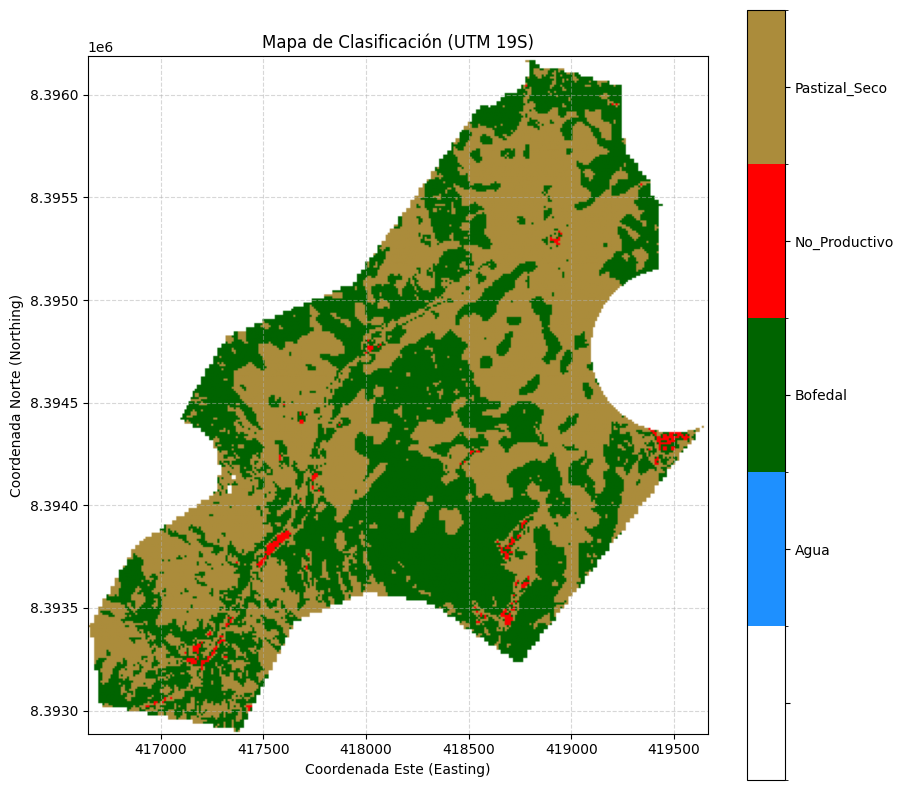

In [356]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio.plot
from rasterio.plot import plotting_extent # Necesitamos importar esto

# 1. Definir los colores y etiquetas para tus clases (esto estaba perfecto)
class_map = {
   -1: ('#FFFFFF', ''),
    0: ('#1E90FF', 'Agua'),
    1: ('#006400', 'Bofedal'),
    2: ('#FF0000', 'No_Productivo'),
    3: ('#ab8c3b', 'Pastizal_Seco')
}

# 2. Crear el Colormap y la Normalización (esto estaba perfecto)
colors = [val[0] for val in class_map.values()]
labels = [val[1] for val in class_map.values()]
bounds = [k - 0.5 for k in class_map.keys()]
bounds.append(max(class_map.keys()) + 0.5)

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 3. Graficar el TIF reproyectado
ruta_a_graficar = ruta_utm_32719
print(f"\nGraficando el mapa de clasificación: {ruta_a_graficar}")

fig, ax = plt.subplots(figsize=(10, 10))

with rasterio.open(ruta_a_graficar) as src:

    # --- INICIO DE LA CORRECCIÓN ---

    # Leemos los datos de la banda 1
    data = src.read(1)

    # Usamos ax.imshow() en lugar de rasterio.plot.show()
    # 'imshow' SÍ devuelve el objeto 'AxesImage' que la colorbar necesita.
    img_plot = ax.imshow(
        data,
        cmap=cmap,         # Aplicar nuestro colormap
        norm=norm,         # Aplicar nuestra norma
        # Usamos 'plotting_extent' para obtener las coordenadas correctas del eje
        extent=plotting_extent(src)
    )

    ax.set_title("Mapa de Clasificación (UTM 19S)")

    # --- FIN DE LA CORRECCIÓN ---

# 4. Configurar la leyenda (Colorbar)
# Ahora 'img_plot' SÍ es un objeto 'mappable' válido
cbar = fig.colorbar(img_plot, ax=ax, ticks=list(class_map.keys()))
cbar.set_ticklabels(labels) # Poner los nombres de las clases
ax.set_xlabel("Coordenada Este (Easting)")
ax.set_ylabel("Coordenada Norte (Northing)")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [296]:
def encontrar_Datos(path):
  ruta_a_mi_tiff = path

  print(f"Verificando datos válidos (estilo .describe()) para: {ruta_a_mi_tiff}\n")

  # Diccionario para guardar los resultados
  all_stats = {}
  hay_datos = False

  try:
      with rasterio.open(ruta_a_mi_tiff) as src:

          nombres_bandas = src.descriptions or [f'Banda_{i+1}' for i in range(src.count)]
          nodata_val = src.nodata

          # Iterar sobre cada banda
          for i, nombre in enumerate(nombres_bandas):
              banda_num = i + 1

              data = src.read(banda_num).astype(float)
              if nodata_val is not None:
                  data[data == nodata_val] = np.nan

              # Conteo de píxeles válidos (no-NaN)
              conteo_valido = np.count_nonzero(~np.isnan(data))

              # Si encontramos datos en CUALQUIER banda, lo marcamos
              if conteo_valido > 0:
                  hay_datos = True

              stats = {
                  'count': conteo_valido,
                  'mean': np.nanmean(data),
                  'std': np.nanstd(data),
                  'min': np.nanmin(data),
                  '25%': np.nanpercentile(data, 25),
                  '50%': np.nanpercentile(data, 50),
                  '75%': np.nanpercentile(data, 75),
                  'max': np.nanmax(data)
              }
              all_stats[nombre] = stats

      # --- 7. Imprimir el DataFrame ---
      df_stats = pd.DataFrame.from_dict(all_stats)

      # Imprimir el resultado principal
      if hay_datos:
          print("✅ ¡Sí! El archivo SÍ tiene datos válidos.")
      else:
          print("❌ No. El archivo está vacío o solo contiene valores NoData.")

      print("\n--- Estadísticas Descriptivas (la fila 'count' lo confirma) ---")
      print(df_stats.round(4))

  except Exception as e:
      print(f"Error al procesar el archivo: {e}")

# mapa Chalhuani

"B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"

variables = ['mean_Green', 'mean_NDVI', 'mean_B5', 'mean_B7',
       'mean_B11', 'mean_B12', 'mean_Temp_Min', 'mean_Temp_Max',
       'mean_Temp_Mean', 'mean_Elevation', 'mean_Evapotranspiration',
       'clip_CIgreen_10m_tamb', 'clip_NDWI_10m_tamb', 'clip_OSAVI_10m_tamb',
       'clip_TNDVI_10m_tamb']

In [332]:
ruta_tiff_1_base = f"{PATH}/Challhuani_10m/composite_green_cigreClen_NDVI_NDWI_OSAVI_TNDVI_10m_renamed.tif"
ruta_tiff_2_agregar = f"/content/drive/MyDrive/DATATHON CIP 2025/Challhuani_10m/ban_10m_chall_S2_B5_B7_B11_B12.tif"
ruta_salida = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas.tif"

# Asegurarse de que el directorio de salida exista
os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

print(f"Abriendo TIF 1 (Plantilla): {ruta_tiff_1_base}...")
# 2. Abre el TIF 1 (la plantilla)
with rasterio.open(ruta_tiff_1_base) as src1:
    # Lee los datos del TIF 1
    data1 = src1.read()

    # Guarda el perfil del TIF 1. Este definirá el TIF final.
    profile = src1.profile
    nombres_bandas_1 = src1.descriptions

    # Obtenemos la información de la cuadrícula de la plantilla
    out_shape = data1.shape[1:] # (filas, columnas)
    out_transform = src1.transform
    out_crs = src1.crs

    print(f"Abriendo TIF 1 (Plantilla): {ruta_tiff_1_base}...")
    with rasterio.open(ruta_tiff_1_base) as src1:
        data1 = src1.read()
        profile = src1.profile
        nombres_bandas_1 = src1.descriptions
        out_shape = data1.shape[1:]
        out_transform = src1.transform
        out_crs = src1.crs

        print(f"Abriendo TIF 2 (Fuente a re-alinear): {ruta_tiff_2_agregar}...")
        with rasterio.open(ruta_tiff_2_agregar) as src2:
            nombres_bandas_2 = src2.descriptions

            print(f"Creando lienzo destino: {src2.count} bandas, {out_shape[0]} filas, {out_shape[1]} columnas")
            data2_resampled = np.empty((src2.count, out_shape[0], out_shape[1]),
                                      dtype=src2.profile['dtype'])

            print(f"Re-alineando TIF 2 (shape {src2.shape}) para que coincida con TIF 1 (shape {data1.shape})...")

            # ========================== INICIO DE LA CORRECCIÓN ==========================
            rasterio.warp.reproject(
                source=rasterio.band(src2, src2.indexes), # <-- AQUÍ ESTÁ EL CAMBIO
                destination=data2_resampled,
                src_transform=src2.transform,
                src_crs=src2.crs,
                dst_transform=out_transform,
                dst_crs=out_crs,
                resampling=rasterio.warp.Resampling.nearest
            )
            # =========================== FIN DE LA CORRECCIÓN ============================

        print("Apilando bandas (ahora con formas idénticas)...")
        data_combinada = np.vstack((data1, data2_resampled))
        nombres_combinados = nombres_bandas_1 + nombres_bandas_2
# --- 4. Actualiza los metadatos para el nuevo archivo ---
profile.update(
    count=data_combinada.shape[0],
    compress='lzw'
)

# --- 5. Escribe el nuevo archivo GeoTIFF ---
print(f"Guardando archivo combinado en {ruta_salida}...")
with rasterio.open(ruta_salida, 'w', **profile) as dst:
    dst.write(data_combinada)

    for i, nombre in enumerate(nombres_combinados):
        # Asegurarse de que el nombre no esté vacío
        if nombre:
            dst.set_band_description(i + 1, nombre)
        else:
            # Poner un nombre genérico si falta
            dst.set_band_description(i + 1, f'Banda_{i+1}')

print("\n--- ¡Proceso completado! ---")
print(f"Archivo 1 tenía {data1.shape[0]} bandas.")
print(f"Archivo 2 (re-alineado) tenía {data2_resampled.shape[0]} bandas.")
print(f"El nuevo archivo tiene {data_combinada.shape[0]} bandas.")
print("Nombres de las bandas:", nombres_combinados)

Abriendo TIF 1 (Plantilla): /content/drive/MyDrive/DATATHON CIP 2025/Challhuani_10m/composite_green_cigreClen_NDVI_NDWI_OSAVI_TNDVI_10m_renamed.tif...
Abriendo TIF 1 (Plantilla): /content/drive/MyDrive/DATATHON CIP 2025/Challhuani_10m/composite_green_cigreClen_NDVI_NDWI_OSAVI_TNDVI_10m_renamed.tif...
Abriendo TIF 2 (Fuente a re-alinear): /content/drive/MyDrive/DATATHON CIP 2025/Challhuani_10m/ban_10m_chall_S2_B5_B7_B11_B12.tif...
Creando lienzo destino: 4 bandas, 372 filas, 475 columnas
Re-alineando TIF 2 (shape (368, 470)) para que coincida con TIF 1 (shape (6, 372, 475))...
Apilando bandas (ahora con formas idénticas)...
Guardando archivo combinado en /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas.tif...

--- ¡Proceso completado! ---
Archivo 1 tenía 6 bandas.
Archivo 2 (re-alineado) tenía 4 bandas.
El nuevo archivo tiene 10 bandas.
Nombres de las bandas: ('Green', 'CIGreen', 'NDVI', 'NDWI', 'OSAVI', 'TNDVI', 'B5', 'B7', 'B11', 'B12')


In [333]:
encontrar_Datos("/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas.tif")

Verificando datos válidos (estilo .describe()) para: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas.tif

✅ ¡Sí! El archivo SÍ tiene datos válidos.

--- Estadísticas Descriptivas (la fila 'count' lo confirma) ---
             Green      CIGreen         NDVI         NDWI        OSAVI  \
count  104065.0000  176224.0000  176224.0000  176224.0000  176224.0000   
mean        0.1039       0.8826       0.2470      -0.2470       0.1140   
std         0.0328       0.7919       0.2127       0.2127       0.1036   
min         0.0138      -0.0057      -0.0084      -0.7307      -0.0898   
25%         0.0821       0.0000       0.0000      -0.4383       0.0000   
50%         0.0989       1.1474       0.3623      -0.3623       0.1478   
75%         0.1190       1.5676       0.4383       0.0000       0.1981   
max         0.4248       5.9823       0.7307       0.0084       0.8258   

             TNDVI           B5           B7          B11          B12  

Banda 1: Green
Banda 2: CIGreen
Banda 3: NDVI
Banda 4: NDWI
Banda 5: OSAVI
Banda 6: TNDVI

In [334]:
variables = ["B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"]

In [335]:
# --- Configuración ---
ruta_original = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas.tif"
ruta_salida_subset = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif"

# 1. Define los NÚMEROS de las bandas que quieres MANTENER
# (Recuerda que rasterio empieza a contar desde 1)
bandas_a_mantener = [1, 3, 7, 8, 9, 10, 2, 4, 5, 6] # Mantenemos solo los 9 índices
# bandas_a_mantener = [10, 11, 12, 13, 14] # Si quisieras solo las 5 bandas crudas

print(f"Abriendo el archivo original: {ruta_original}")
with rasterio.open(ruta_original) as src:

    # 2. Lee solo los datos de las bandas que quieres
    data_subset = src.read(bandas_a_mantener)

    # 3. Obtén los nombres de esas bandas (para mantenerlos)
    nombres_originales = src.descriptions
    nombres_subset = [nombres_originales[i - 1] for i in bandas_a_mantener]

    # 4. Copia el perfil (metadatos) y actualízalo
    profile = src.profile
    profile.update(
        count=len(bandas_a_mantener), # Actualiza el número de bandas
        compress='lzw'                 # (Opcional, pero recomendado)
    )

    print(f"Creando el nuevo archivo con {len(bandas_a_mantener)} bandas: {ruta_salida_subset}")

    # 5. Escribe el nuevo archivo TIF
    with rasterio.open(ruta_salida_subset, 'w', **profile) as dst:
        # Escribe los datos
        dst.write(data_subset)

        # Asigna los nombres correctos al nuevo archivo
        for i, nombre in enumerate(nombres_subset):
            dst.set_band_description(i + 1, nombre)

print("¡Proceso de 'borrado' (subconjunto) completado!")

Abriendo el archivo original: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas.tif
Creando el nuevo archivo con 10 bandas: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif
¡Proceso de 'borrado' (subconjunto) completado!


In [336]:
encontrar_Datos("/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif")

Verificando datos válidos (estilo .describe()) para: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif

✅ ¡Sí! El archivo SÍ tiene datos válidos.

--- Estadísticas Descriptivas (la fila 'count' lo confirma) ---
             Green         NDVI           B5           B7          B11  \
count  104065.0000  176224.0000  105008.0000  105008.0000  105008.0000   
mean        0.1039       0.2470    1808.5417    2342.0684    3803.9935   
std         0.0328       0.2127     417.7639     538.4239     767.3911   
min         0.0138      -0.0084       0.0000       0.0000       0.0000   
25%         0.0821       0.0000    1699.1090    2196.2166    3767.6779   
50%         0.0989       0.3623    1864.1961    2419.4733    3963.5322   
75%         0.1190       0.4383    2023.4336    2629.3964    4108.2837   
max         0.4248       0.7307    2978.7600    3661.5386    5002.3198   

               B12      CIGreen         NDWI        OSAVI        TNDVI

In [337]:
ruta_a_mi_tiff = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif"

try:
    # 2. Abre el archivo GeoTIFF
    with rasterio.open(ruta_a_mi_tiff) as dataset:

        print(f"--- Información del archivo: {dataset.name} ---")

        # 3. Obtiene el número total de bandas
        num_bandas = dataset.count
        print(f"Número total de bandas: {num_bandas}")

        # 4. Obtiene los nombres (descripciones) de las bandas
        # GEE guarda aquí los nombres que pusiste con .rename()
        nombres_bandas = dataset.descriptions

        # 5. Obtiene los números (índices) de las bandas
        indices_bandas = dataset.indexes

        print("\n--- Lista de Bandas (Número: Nombre) ---")

        # 6. Combina los números y nombres y los imprime
        if nombres_bandas: # Si la lista de nombres no está vacía
            for numero, nombre in zip(indices_bandas, nombres_bandas):
                print(f"Banda {numero}: {nombre}")
        else:
            # A veces los TIF no tienen nombres guardados
            print(f"El archivo no tiene nombres de banda. Los índices son: {indices_bandas}")

except FileNotFoundError:
    print(f"Error: No se pudo encontrar el archivo en la ruta:")
    print(f"{ruta_a_mi_tiff}")
    print("Verifica que la ruta y el nombre del archivo sean correctos.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

--- Información del archivo: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif ---
Número total de bandas: 10

--- Lista de Bandas (Número: Nombre) ---
Banda 1: Green
Banda 2: NDVI
Banda 3: B5
Banda 4: B7
Banda 5: B11
Banda 6: B12
Banda 7: CIGreen
Banda 8: NDWI
Banda 9: OSAVI
Banda 10: TNDVI


In [338]:
variables = ["B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"]

In [339]:
# --- Configuración ---
ruta_original = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif"
ruta_salida_nombres = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif"

# 1. Define la LISTA COMPLETA de nuevos nombres
# (Debe tener EXACTAMENTE el mismo número de bandas que el original)
nuevos_nombres = [
   "B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"
]

print(f"Abriendo el archivo original: {ruta_original}")
with rasterio.open(ruta_original) as src:

    # Verifica que la lista de nombres coincida
    if len(nuevos_nombres) != src.count:
        print(f"Error: El TIF tiene {src.count} bandas, pero diste {len(nuevos_nombres)} nombres.")
    else:
        # 2. Lee TODOS los datos
        data = src.read()

        # 3. Copia el perfil (metadatos)
        profile = src.profile
        profile.update(compress='lzw') # (Opcional)

        print(f"Creando copia con nombres nuevos: {ruta_salida_nombres}")

        # 4. Escribe el nuevo archivo
        with rasterio.open(ruta_salida_nombres, 'w', **profile) as dst:
            dst.write(data)

            # 5. Asigna los nuevos nombres
            for i, nombre in enumerate(nuevos_nombres):
                dst.set_band_description(i + 1, nombre)

print("¡Proceso de renombrado completado!")

Abriendo el archivo original: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif
Creando copia con nombres nuevos: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif
¡Proceso de renombrado completado!


In [340]:
encontrar_Datos("/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif")

Verificando datos válidos (estilo .describe()) para: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif

✅ ¡Sí! El archivo SÍ tiene datos válidos.

--- Estadísticas Descriptivas (la fila 'count' lo confirma) ---
                B3         NDVI           B5           B7          B11  \
count  104065.0000  176224.0000  105008.0000  105008.0000  105008.0000   
mean        0.1039       0.2470    1808.5417    2342.0684    3803.9935   
std         0.0328       0.2127     417.7639     538.4239     767.3911   
min         0.0138      -0.0084       0.0000       0.0000       0.0000   
25%         0.0821       0.0000    1699.1090    2196.2166    3767.6779   
50%         0.0989       0.3623    1864.1961    2419.4733    3963.5322   
75%         0.1190       0.4383    2023.4336    2629.3964    4108.2837   
max         0.4248       0.7307    2978.7600    3661.5386    5002.3198   

               B12      CIgreen         NDWI        OSAVI        TNDVI

In [290]:
variables = ["B3","NDVI","B5","B7","B11","B12","CIgreen","NDWI","OSAVI","TNDVI"]

## PREDICT

In [341]:
# ================================================================

# 6️⃣ APLICAR MODELO A RASTER MULTIBANDA

# ================================================================

ruta_tif = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Bandas_completas_1.tif"

with rasterio.open(ruta_tif) as src:
    img = src.read()  # (bandas, filas, columnas)
    profile = src.profile # Guarda el perfil para exportar después

print(f"\nBandas encontradas en el raster: {img.shape[0]}")

if img.shape[0] < len(variables):
    raise ValueError("El raster no contiene todas las bandas esperadas.")

# 1. PREPARAR DATOS
# ----------------------------------------------------------------
# Reorganizar a (píxeles, bandas)
n_bands, n_rows, n_cols = img.shape
pixels = img.reshape(n_bands, -1).T
X_raster = pd.DataFrame(pixels, columns=variables)

# Reemplazar infinitos por NaN
X_raster.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. SEPARAR PÍXELES VÁLIDOS Y NULOS
# ----------------------------------------------------------------
# Crear una máscara booleana: True para filas sin ningún NaN
valid_pixels_mask = ~X_raster.isnull().any(axis=1)

# Crear el DataFrame solo con los datos válidos que se procesarán
X_raster_valid = X_raster[valid_pixels_mask]


Bandas encontradas en el raster: 10


In [318]:
X_raster_valid.columns

Index(['B3', 'NDVI', 'B5', 'B7', 'B11', 'B12', 'CIgreen', 'NDWI', 'OSAVI',
       'TNDVI'],
      dtype='object')

In [323]:
X_raster_valid[X_raster_valid['B11'] !=  0].describe()

,B3,NDVI,B5,B7,B11,B12,CIgreen,NDWI,OSAVI,TNDVI
count,101131.000000,101131.000000,101131.000000,101131.000000,101131.000000,101131.000000,101131.000000,101131.000000,101131.000000,101131.000000
mean,0.103911,0.420428,1875.346436,2428.628906,3944.488037,2743.128906,1.502427,-0.420428,0.194051,0.857094
std,0.032802,0.066108,235.977463,300.820312,237.658173,197.875381,0.372756,0.066108,0.053044,0.034462
min,0.013805,-0.005898,753.200012,917.559998,2306.679932,1707.359985,-0.002857,-0.730672,-0.089821,0.620699
25%,0.082057,0.389344,1721.000000,2225.177734,3792.260986,2615.399902,1.283516,-0.459359,0.163387,0.837672
50%,0.098894,0.430060,1874.076904,2432.800049,3975.476074,2740.159180,1.515815,-0.430060,0.190434,0.854870
75%,0.119013,0.459359,2029.044434,2637.692383,4113.192383,2864.976807,1.707125,-0.389344,0.222089,0.876134
max,0.424794,0.730672,2978.760010,3661.538574,5002.319824,4119.359863,5.982264,0.005898,0.825795,1.138554


In [319]:
gdf_puntos_1[['B3', 'NDVI', 'B5', 'B7', 'B11', 'B12', 'CIgreen', 'NDWI', 'OSAVI',
       'TNDVI']].describe()

,B3,NDVI,B5,B7,B11,B12,CIgreen,NDWI,OSAVI,TNDVI
count,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000
mean,0.121631,0.233992,1783.257227,2303.012325,3538.823922,2414.356078,1.042447,-0.336587,0.271419,0.855829
std,0.021031,0.068955,291.725246,364.049740,430.524741,314.904460,0.301852,0.062079,0.079984,0.039392
min,0.075400,0.082901,1089.000000,1379.000000,2222.000000,1541.000000,0.340598,-0.570706,0.096162,0.763479
25%,0.106400,0.192443,1588.000000,2059.000000,3274.000000,2220.000000,0.880081,-0.369014,0.223227,0.832132
50%,0.120100,0.221083,1764.000000,2284.000000,3610.000000,2418.000000,1.011058,-0.335782,0.256446,0.849166
75%,0.133400,0.263135,1966.000000,2572.000000,3839.000000,2631.000000,1.169643,-0.305575,0.305225,0.873576
max,0.202200,0.549430,3211.500000,3826.000000,4646.000000,3295.000000,2.658810,-0.145517,0.637314,1.024417


In [321]:
X_raster_valid[X_raster_valid['B11'] > 50]

,B3,NDVI,B5,B7,B11,B12,CIgreen,NDWI,OSAVI,TNDVI
2715,0.146523,0.261799,2575.404297,2892.319092,4396.361816,3353.680908,0.713070,-0.261799,0.090714,0.775452
2716,0.157234,0.235787,2575.404297,2892.319092,4396.361816,3353.680908,0.621438,-0.235787,0.091746,0.773059
2717,0.212319,0.218761,2653.595703,2949.765869,4433.702148,3361.914795,0.565077,-0.218761,0.084892,0.767043
2718,0.250073,0.192621,2653.595703,2949.765869,4433.702148,3361.914795,0.478379,-0.192621,0.061254,0.750111
2719,0.288019,0.191814,2864.688965,3124.555664,4522.666504,3365.133301,0.484353,-0.191814,0.070614,0.756948
...,...,...,...,...,...,...,...,...,...,...
174459,0.127946,0.161408,2545.639893,3236.199951,3962.040039,2547.040039,0.605775,-0.161408,0.074084,0.758538
174460,0.122025,0.452939,2545.639893,3236.199951,3962.040039,2547.040039,1.666381,-0.452939,0.206740,0.852331
174461,0.126096,0.451079,2580.479980,3237.120117,4115.240234,2681.879883,1.710404,-0.451079,0.198388,0.845947
174934,0.135116,0.000000,2545.639893,3236.199951,3962.040039,2547.040039,0.000000,0.000000,0.000000,0.707107


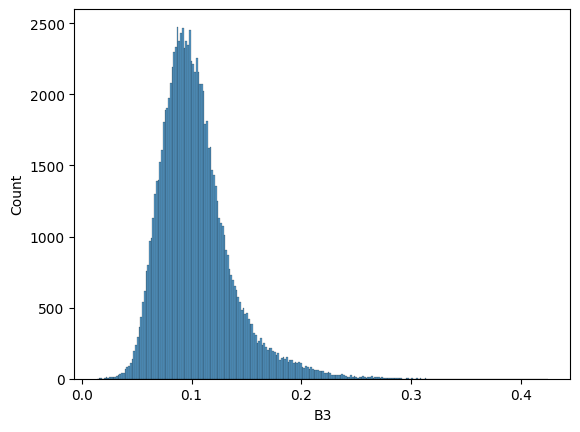

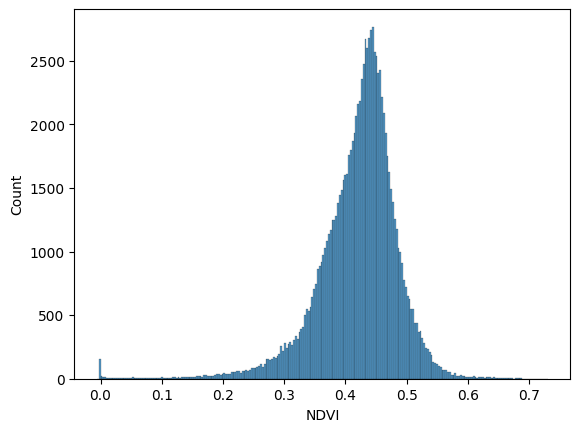

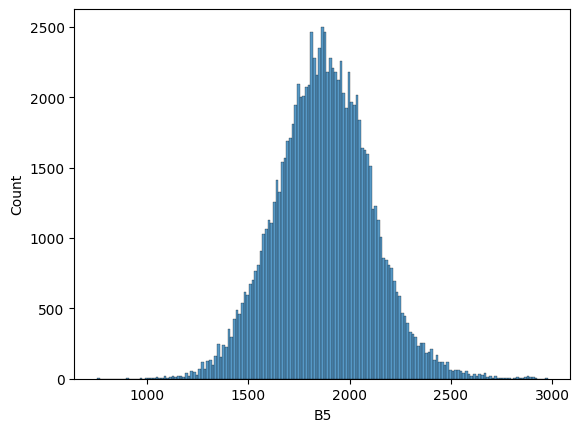

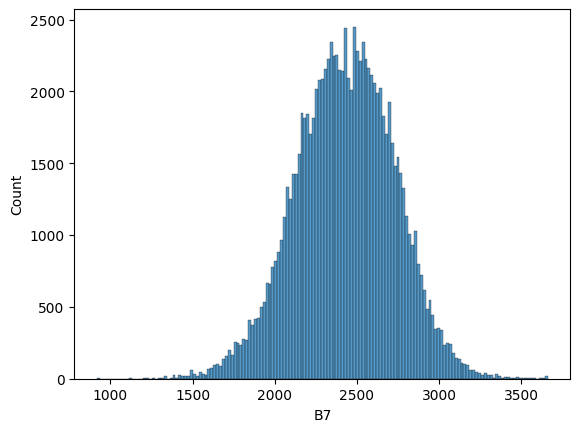

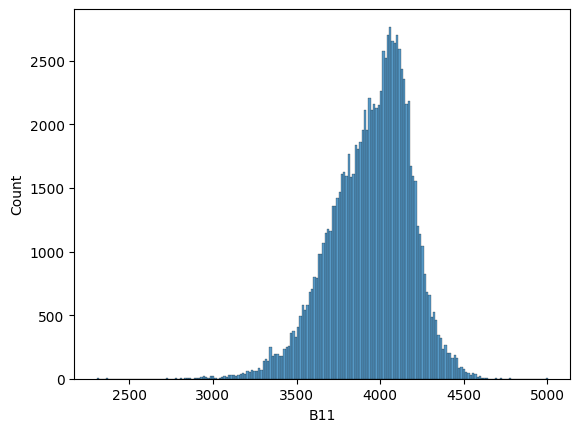

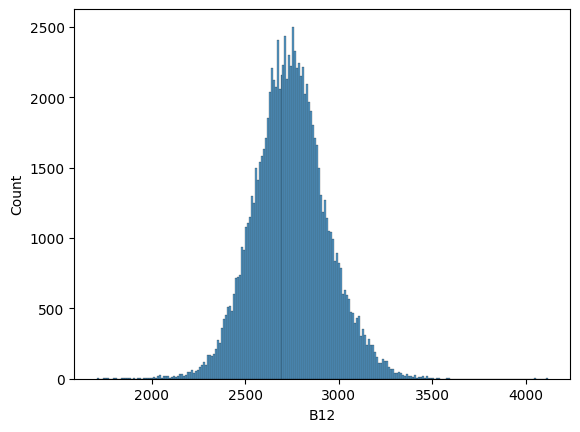

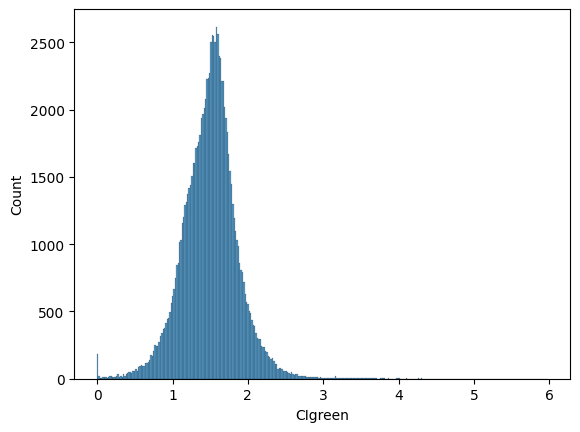

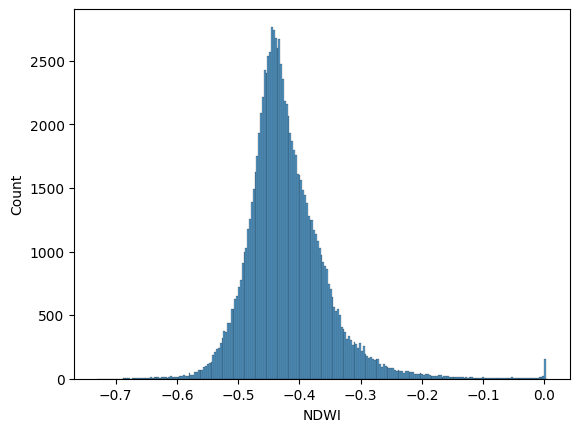

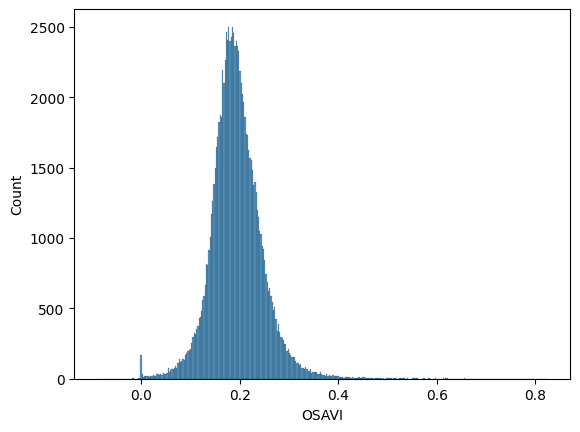

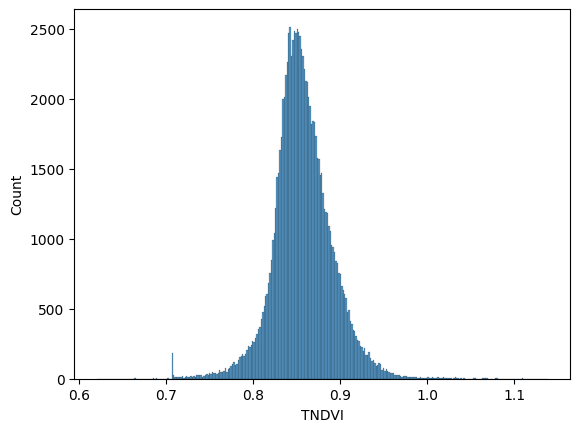

In [328]:
var = ['B3', 'NDVI', 'B5', 'B7', 'B11', 'B12', 'CIgreen', 'NDWI', 'OSAVI',
       'TNDVI']
for i in var:
  sns.histplot(X_raster_valid[X_raster_valid['B11'] > 50][i])
  plt.show()

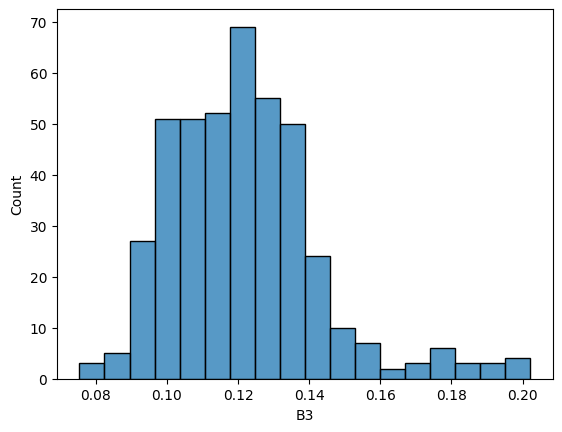

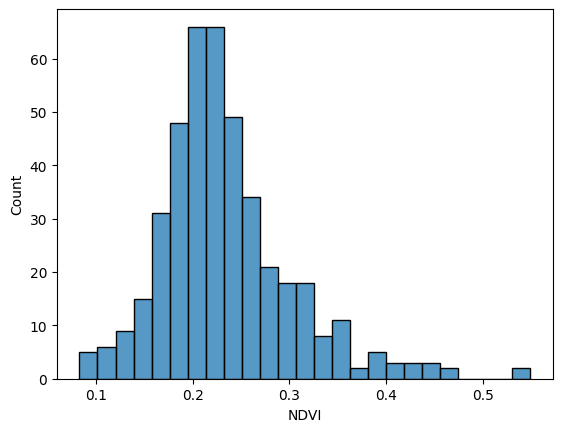

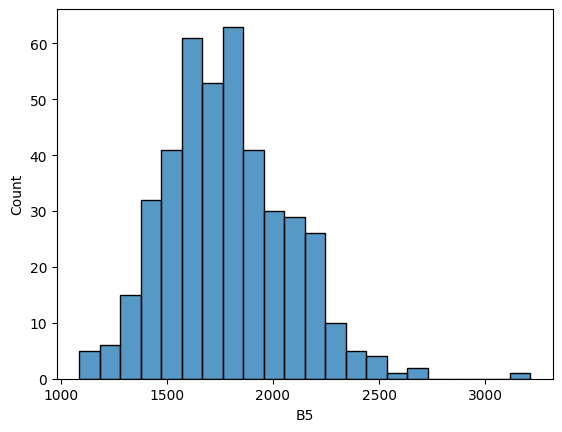

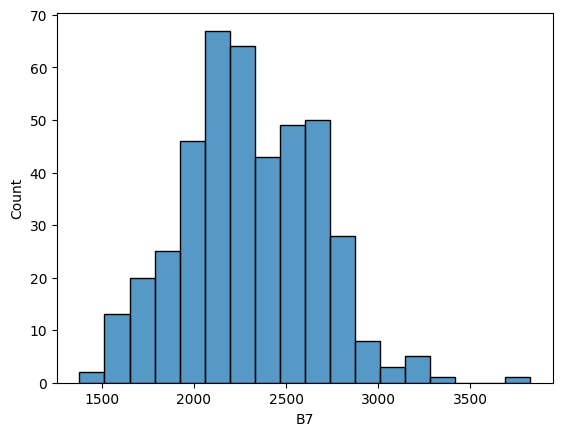

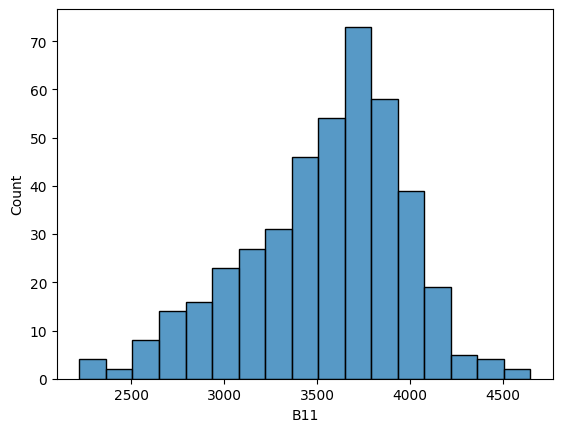

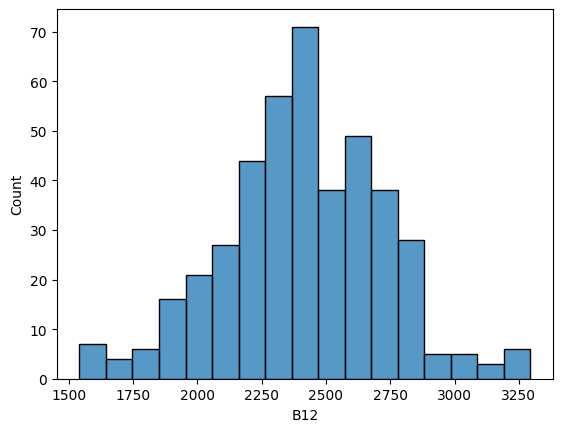

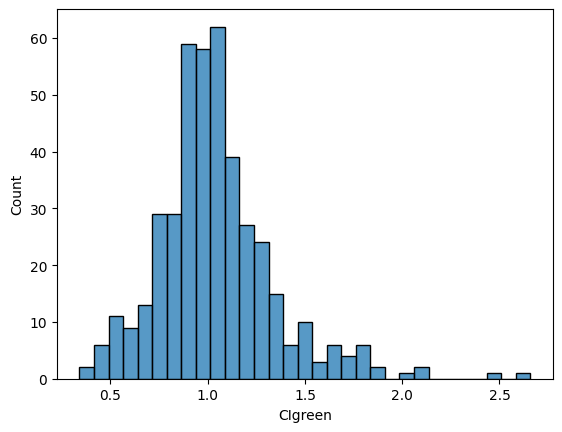

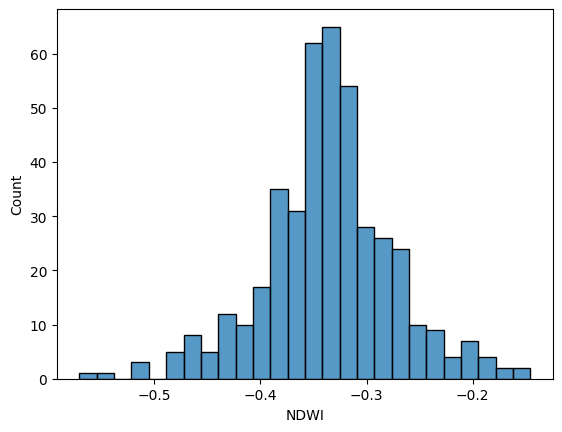

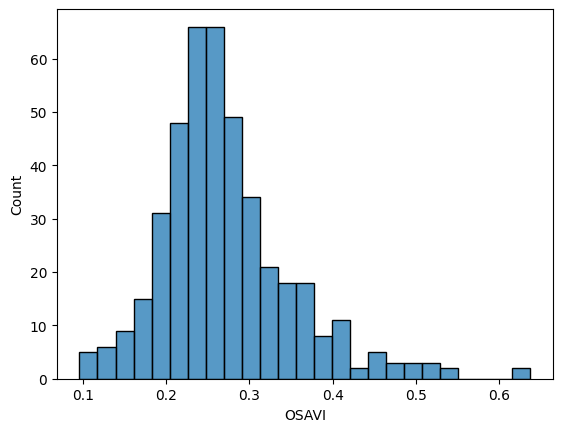

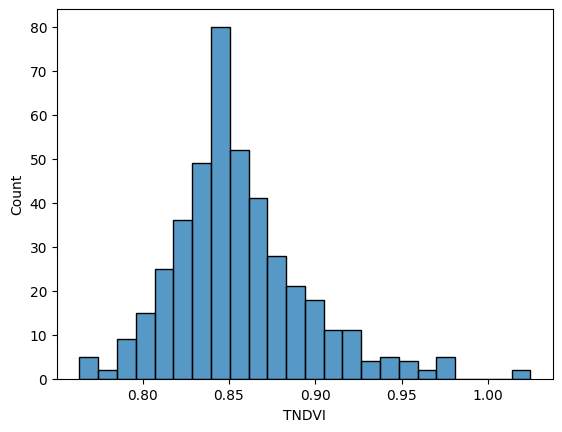

In [327]:
var = ['B3', 'NDVI', 'B5', 'B7', 'B11', 'B12', 'CIgreen', 'NDWI', 'OSAVI',
       'TNDVI']
for i in var:
  sns.histplot(gdf_puntos_1[i])
  plt.show()

In [325]:
unique, counts = np.unique(predictions_str, return_counts=True)
dict(zip(unique, counts))

{np.int32(0): np.int64(12),
 np.int32(1): np.int64(99321),
 np.int32(2): np.int64(1185),
 np.int32(3): np.int64(617)}

In [310]:
predictions_str

array([2, 2, 1, ..., 1, 2, 2], dtype=int32)

In [343]:
# 3. APLICAR MODELO (SOLO A DATOS VÁLIDOS)
# ----------------------------------------------------------------

# Crear un array para el resultado final, inicializado con NaN
final_prediction = np.full(X_raster.shape[0], np.nan)

# Proceder solo si hay píxeles válidos que procesar
if not X_raster_valid.empty:
    # Estandarizar únicamente los datos válidos
    X_raster_valid_scaled = scaler.transform(X_raster_valid)

    # Predecir sobre los datos estandarizados (ESTO DEVUELVE STRINGS)
    predictions_str = best_model_tree.predict(X_raster_valid_scaled)

    # ========================== INICIO DE LA CORRECCIÓN ==========================

    # 1. Crear un mapa para "traducir" de string (texto) a int (número)
    #    Estos números (1, 2, 3, 4) serán los valores de tu raster final.
    mapa_str_a_int = {
            'Pastizal_Seco': 1,
            'Bofedal': 2,
            'No_Productivo': 3,
            'Agua': 4
        }
    # 2. Aplicar el mapa. Usamos pd.Series().map() que es muy rápido
    #    El resultado es un array de números (ej: [1, 2, 1, 3, 4, ...])
    predictions_int = pd.Series(predictions_str).map(mapa_str_a_int).to_numpy()

    # 3. Insertar las predicciones numéricas (int) en el array de floats
    #    (Esto funciona porque un int SÍ se puede guardar en un array float)
    final_prediction[valid_pixels_mask] = predictions_int

    # =========================== FIN DE LA CORRECCIÓN ============================

# 4. RECONSTRUIR EL RASTER DE SALIDA
# ----------------------------------------------------------------
# Reconvertir el vector de predicciones a su forma matricial (filas, columnas)
# Este array todavía es de tipo 'float' y tiene 'NaN's
prediction_reshaped = final_prediction.reshape(n_rows, n_cols)

print("\nProceso de predicción completado.")
print(f"Píxeles procesados: {len(X_raster_valid)}")
print(f"Píxeles con NaN (ignorados): {np.isnan(prediction_reshaped).sum()}")


# 5. EXPORTAR EL RASTER DE CLASIFICACIÓN FINAL
# ----------------------------------------------------------------
# Los mapas de clasificación deben ser enteros (int), no flotantes (float).
# Vamos a convertir los NaN a un valor 'nodata' (ej: 0) y cambiar el tipo.
nodata_value = -1 # Valor para los píxeles NaN (fondo)
prediction_final = np.nan_to_num(prediction_reshaped, nan=nodata_value).astype(np.int16)

# Actualizar el perfil (metadatos) del TIF de salida
profile.update(
    dtype=np.int16,  # Tipo de dato entero
    count=1,         # El TIF de salida solo tiene 1 banda
    nodata=nodata_value # Indicar cuál es el valor 'sin datos'
)

# Definir la ruta de salida
ruta_salida_tif = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge.tif"

# Escribir el archivo
with rasterio.open(ruta_salida_tif, 'w', **profile) as dst:
    dst.write(prediction_final, 1) # Escribir los datos en la banda 1

print(f"\n¡Mapa de clasificación guardado exitosamente en:")
print(ruta_salida_tif)


Proceso de predicción completado.
Píxeles procesados: 101135
Píxeles con NaN (ignorados): 75565

¡Mapa de clasificación guardado exitosamente en:
/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge.tif


In [344]:
encontrar_Datos("/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge.tif")

Verificando datos válidos (estilo .describe()) para: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge.tif

✅ ¡Sí! El archivo SÍ tiene datos válidos.

--- Estadísticas Descriptivas (la fila 'count' lo confirma) ---
              None
count  101135.0000
mean        2.1462
std         1.0009
min         1.0000
25%         1.0000
50%         3.0000
75%         3.0000
max         4.0000


In [345]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS

# --- Configuración ---
# 1. El TIF que acabas de guardar (probablemente en 4326)
ruta_original = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge.tif"
# 2. El nombre del nuevo TIF que vamos a crear
ruta_utm_32719 = f"{PATH}/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge_UTM.tif"
# 3. El CRS de destino que pediste
target_crs = CRS.from_epsg(32719)

print(f"Reproyectando {ruta_original} a EPSG:32719...")

# Abrir el TIF original
with rasterio.open(ruta_original) as src:
    print(f"CRS original: {src.crs}")

    # Calcular la transformación y dimensiones para el nuevo CRS
    transform, width, height = calculate_default_transform(
        src.crs, target_crs, src.width, src.height, *src.bounds)

    # Copiar los metadatos y actualizarlos
    profile = src.profile
    profile.update({
        'crs': target_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    # Escribir el nuevo archivo TIF reproyectado
    with rasterio.open(ruta_utm_32719, 'w', **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest # ¡MUY IMPORTANTE para clasificación!
        )

print(f"\n¡Archivo reproyectado guardado en:")
print(ruta_utm_32719)

Reproyectando /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge.tif a EPSG:32719...
CRS original: EPSG:32719

¡Archivo reproyectado guardado en:
/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge_UTM.tif


In [346]:
import rasterio
import numpy as np

# 1. Ruta a tu TIF de clasificación (el que ya tiene valores 0, 1, 2, 3, 255)
ruta_clasificacion = f"/content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge_UTM.tif"

print(f"Analizando los valores en: {ruta_clasificacion}\n")

try:
    with rasterio.open(ruta_clasificacion) as src:

        # Leer la banda 1
        data = src.read(1)

        # Obtener el valor 'NoData' (que definimos como 255)
        nodata_val = src.nodata

        # --- El Paso Clave ---

        # 1. Aplanar el array 2D a 1D
        data_flat = data.flatten()

        # 2. Filtrar y quitar los píxeles 'NoData'
        #    Esto es crucial para que no cuente el fondo
        data_valid = data_flat[data_flat != nodata_val]

        # 3. Obtener los valores únicos y su conteo
        #    Aquí está la magia
        valores, conteos = np.unique(data_valid, return_counts=True)

        # --- Mostrar los resultados ---
        print("--- Conteo de Píxeles por Clase (Frecuencia) ---")

        # Convertir a un diccionario para verlo bonito
        resultados = dict(zip(valores, conteos))
        print(resultados)

        # (BONUS) Calcular porcentajes
        total_pixeles_validos = len(data_valid)
        print(f"\nTotal de píxeles clasificados: {total_pixeles_validos:,.0f}")
        print("\n--- Porcentaje de Área por Clase ---")

        # Re-usamos tu mapa de clases para las etiquetas
        mapa_etiquetas = {
            0: 'Agua',
            1: 'Bofedal',
            2: 'No_Productivo',
            3: 'Pastizal_Seco'
        }

        for valor, conteo in resultados.items():
            etiqueta = mapa_etiquetas.get(valor, f'Valor_{valor}')
            porcentaje = (conteo / total_pixeles_validos) * 100
            print(f"  Clase {int(valor)} ({etiqueta}): {porcentaje:.2f}%  ({conteo:,.0f} píxeles)")

except Exception as e:
    print(f"Error al procesar el archivo: {e}")

Analizando los valores en: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge_UTM.tif

--- Conteo de Píxeles por Clase (Frecuencia) ---
{np.int16(1): np.int64(43114), np.int16(2): np.int64(1351), np.int16(3): np.int64(55439), np.int16(4): np.int64(1231)}

Total de píxeles clasificados: 101,135

--- Porcentaje de Área por Clase ---
  Clase 1 (Bofedal): 42.63%  (43,114 píxeles)
  Clase 2 (No_Productivo): 1.34%  (1,351 píxeles)
  Clase 3 (Pastizal_Seco): 54.82%  (55,439 píxeles)
  Clase 4 (Valor_4): 1.22%  (1,231 píxeles)



Graficando el mapa de clasificación: /content/drive/MyDrive/DATATHON CIP 2025/COBERTURA PICOTANI/TIF_FINALES/CHALHU/Clasificacion_Ridge_UTM.tif


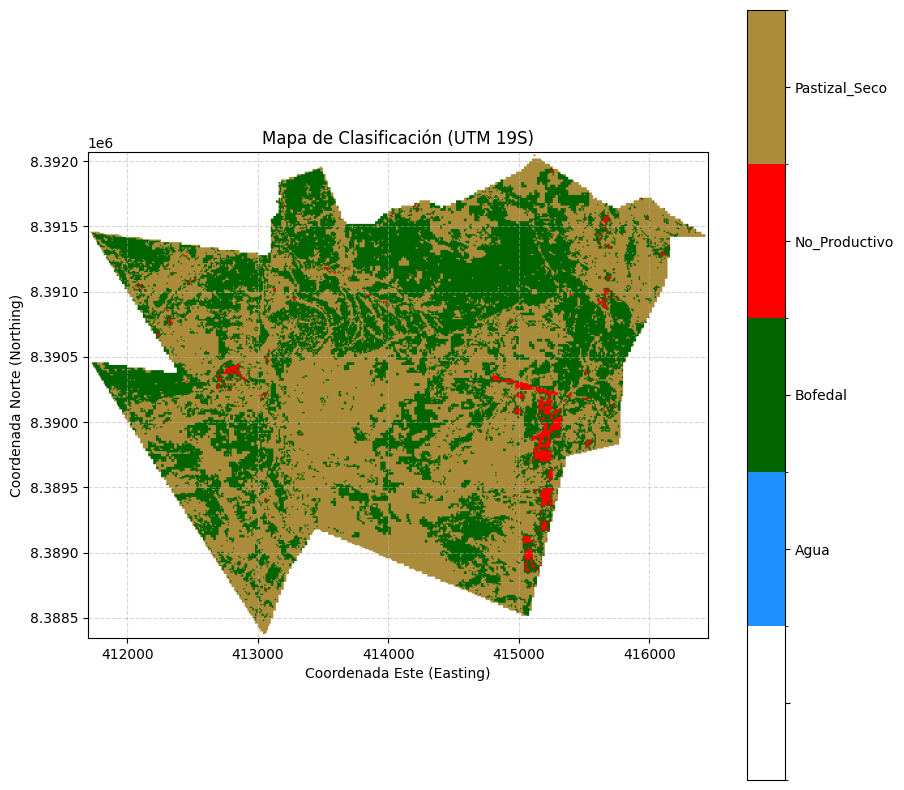

In [347]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio.plot
from rasterio.plot import plotting_extent # Necesitamos importar esto

# 1. Definir los colores y etiquetas para tus clases (esto estaba perfecto)
class_map = {
   -1: ('#FFFFFF', ''),
    0: ('#1E90FF', 'Agua'),
    1: ('#006400', 'Bofedal'),
    2: ('#FF0000', 'No_Productivo'),
    3: ('#ab8c3b', 'Pastizal_Seco')
}

# 2. Crear el Colormap y la Normalización (esto estaba perfecto)
colors = [val[0] for val in class_map.values()]
labels = [val[1] for val in class_map.values()]
bounds = [k - 0.5 for k in class_map.keys()]
bounds.append(max(class_map.keys()) + 0.5)

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 3. Graficar el TIF reproyectado
ruta_a_graficar = ruta_utm_32719
print(f"\nGraficando el mapa de clasificación: {ruta_a_graficar}")

fig, ax = plt.subplots(figsize=(10, 10))

with rasterio.open(ruta_a_graficar) as src:

    # --- INICIO DE LA CORRECCIÓN ---

    # Leemos los datos de la banda 1
    data = src.read(1)

    # Usamos ax.imshow() en lugar de rasterio.plot.show()
    # 'imshow' SÍ devuelve el objeto 'AxesImage' que la colorbar necesita.
    img_plot = ax.imshow(
        data,
        cmap=cmap,         # Aplicar nuestro colormap
        norm=norm,         # Aplicar nuestra norma
        # Usamos 'plotting_extent' para obtener las coordenadas correctas del eje
        extent=plotting_extent(src)
    )

    ax.set_title("Mapa de Clasificación (UTM 19S)")

    # --- FIN DE LA CORRECCIÓN ---

# 4. Configurar la leyenda (Colorbar)
# Ahora 'img_plot' SÍ es un objeto 'mappable' válido
cbar = fig.colorbar(img_plot, ax=ax, ticks=list(class_map.keys()))
cbar.set_ticklabels(labels) # Poner los nombres de las clases
ax.set_xlabel("Coordenada Este (Easting)")
ax.set_ylabel("Coordenada Norte (Northing)")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()